# Análise Exploratória de Dados — Licitações PNCP

EDA sobre a base analítica gerada pelo pipeline `licitacoes.ipynb`.

**Seções:**
- 8. Análise Exploratória (EDA)
- 9. Análise Temporal

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from viz import *

warnings.filterwarnings('ignore')

ARQUIVO_FINAL = Path('base_analitica_licitacoes_tratada.parquet')

df_eda = pd.read_parquet(ARQUIVO_FINAL)
print(f'Base EDA: {df_eda.shape}')

8. Análise Exploratória (EDA)

Base EDA: (4250863, 92)


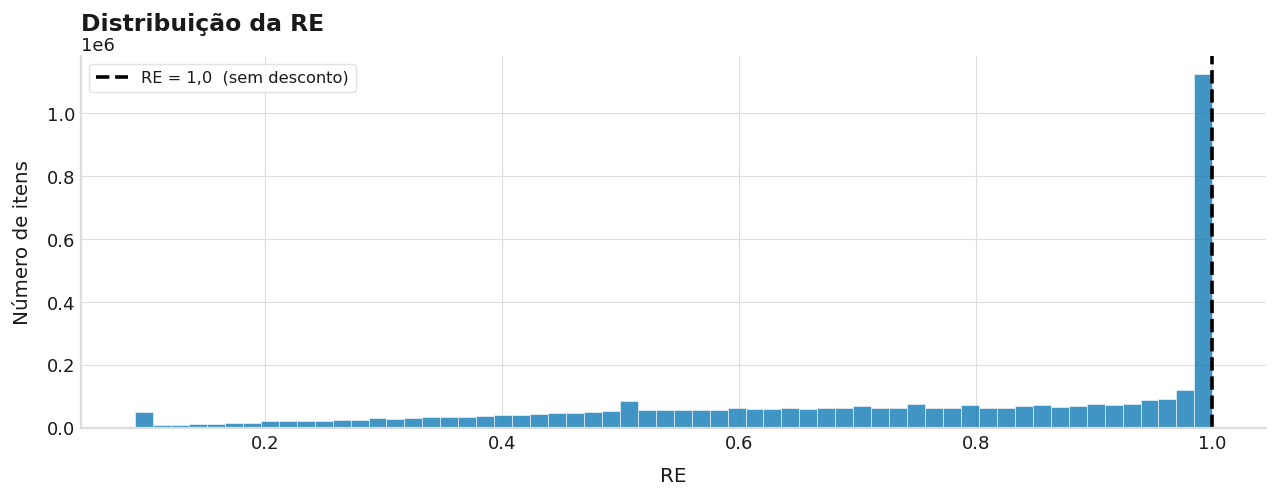

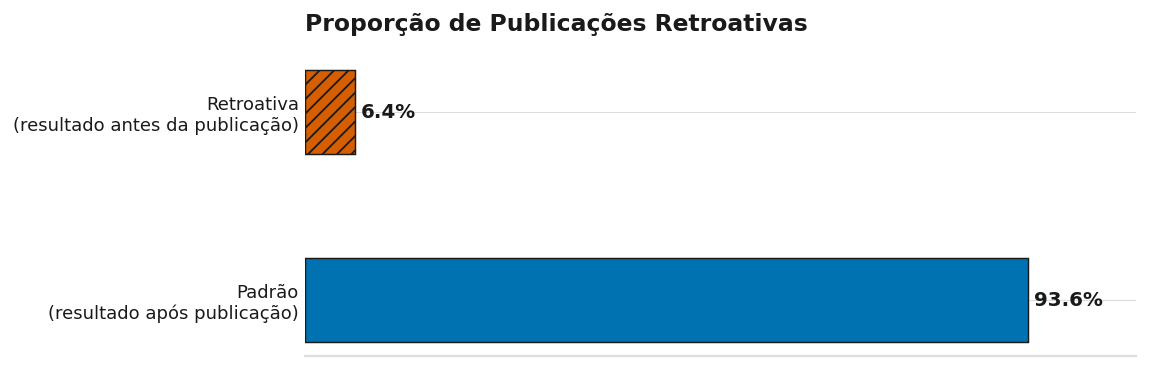

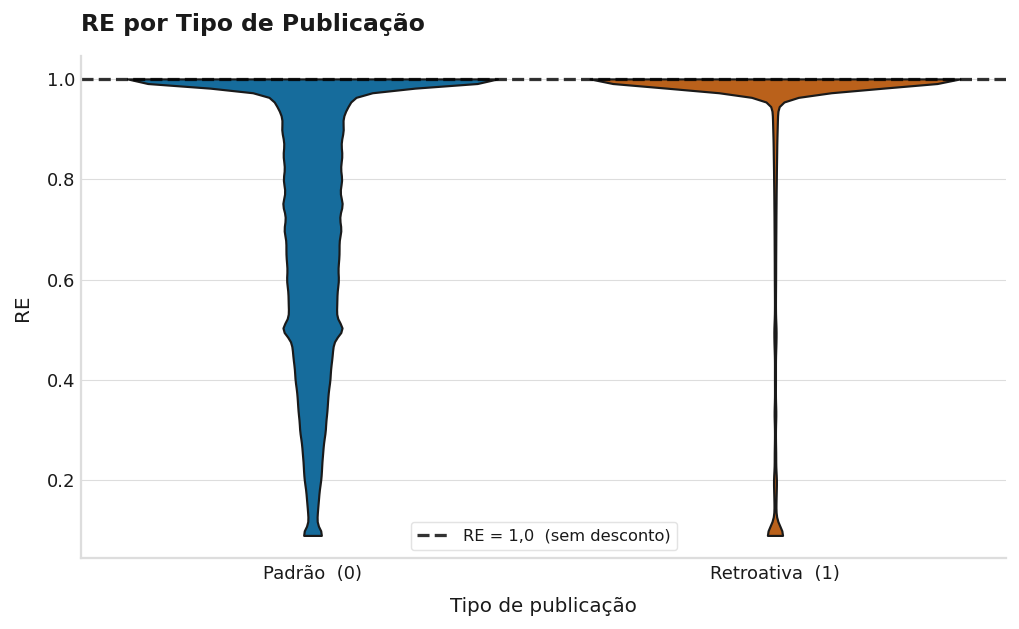

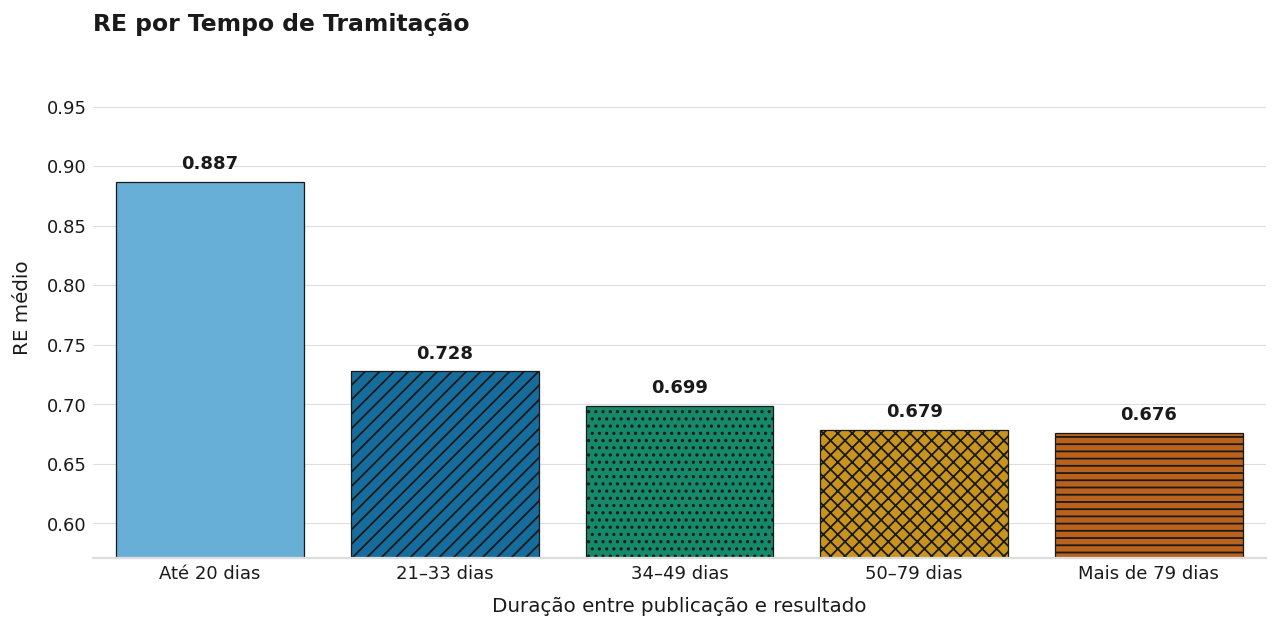

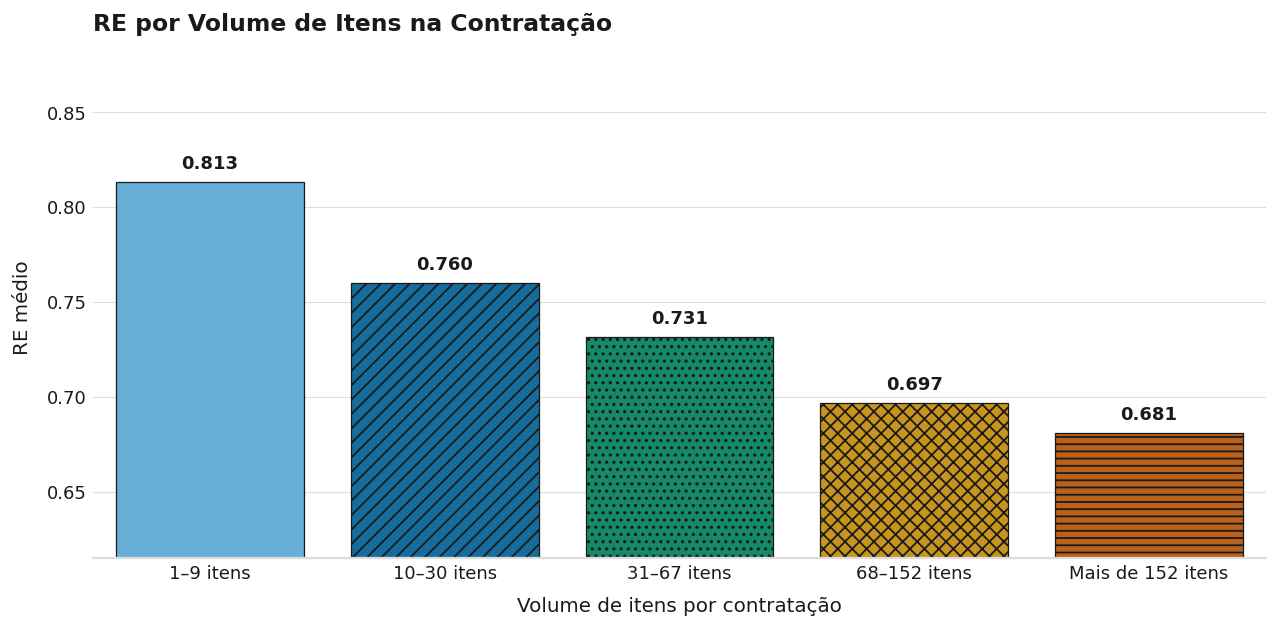

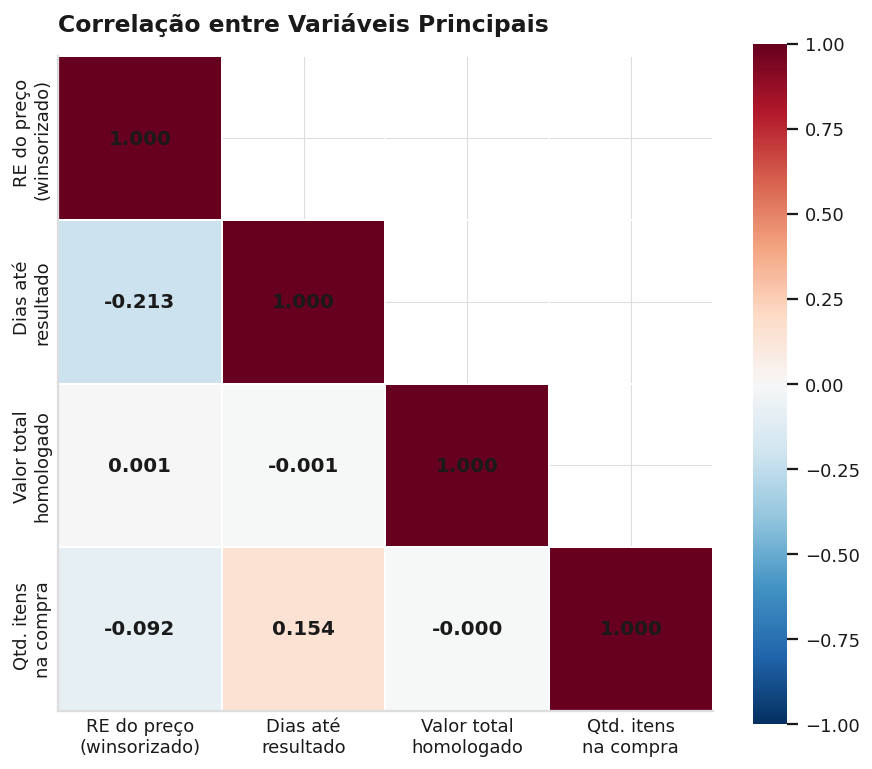

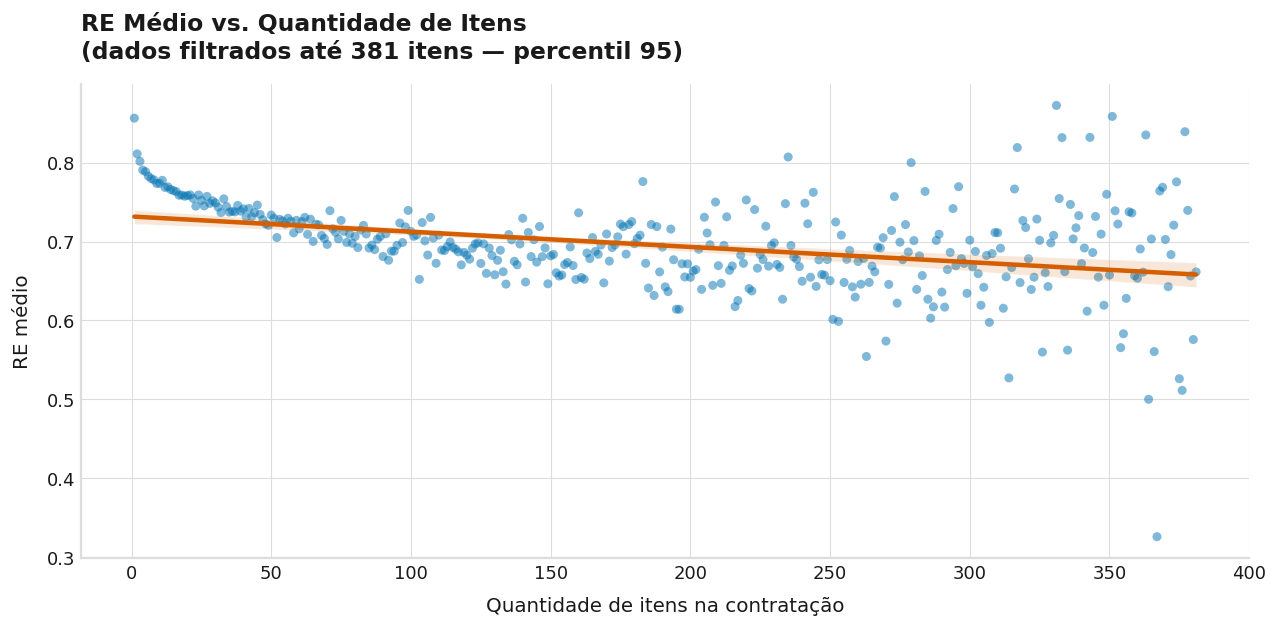


Top modalidades:
modalidade_nome
Pregão - Eletrônico          3150691
Dispensa                      784134
Inexigibilidade               172494
None                          109293
Concorrência - Eletrônica      19488
Credenciamento                 11258
Pregão - Presencial             2605
Concorrência - Presencial        896
Concurso                           4
Name: count, dtype: int64

 EDA concluída.


In [12]:
# ── 8.1 Distribuição da razão de preço (winsorizada) ──────────────────────
if "ratio_preco_total_wins" in df_eda.columns:
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(
        df_eda["ratio_preco_total_wins"],
        bins=60,
        color=AZUL_OI,
        edgecolor=FUNDO,
        linewidth=0.3,
        ax=ax,
    )
    ax.axvline(1.0, color=PRETO_OI, linewidth=2.0, linestyle="--",
               label="RE = 1,0  (sem desconto)")
    ax.legend(fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)
    _estilizar(
        ax,
        titulo="Distribuição da RE",
        xlabel="RE",
        ylabel="Número de itens",
    )
    salvar_ou_mostrar(fig)


# ── 8.2 Publicação retroativa ──────────────────────────────────────────────
if "flag_publicacao_retroativa" in df_eda.columns:

    # 8.2a — Proporção
    dados   = df_eda["flag_publicacao_retroativa"].value_counts(normalize=True) * 100
    rotulos = [
        "Padrão\n(resultado após publicação)",
        "Retroativa\n(resultado antes da publicação)",
    ]

    fig, ax = plt.subplots(figsize=(9, 3))
    bars = ax.barh(
        rotulos, dados.values,
        color=PALETA_OI_2,
        height=0.45,
        edgecolor=CINZA_TEXT,
        linewidth=0.8,
    )
    bars[1].set_hatch("///")
    bars[1].set_edgecolor(CINZA_TEXT)

    for bar, val in zip(bars, dados.values):
        ax.text(
            bar.get_width() + 0.8,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%",
            va="center", fontsize=11, fontweight="bold", color=CINZA_TEXT,
        )
    ax.set_xlim(0, dados.max() * 1.15)
    ax.xaxis.set_visible(False)
    _estilizar(
        ax,
        titulo="Proporção de Publicações Retroativas",
        xlabel="Percentual dos resultados (%)",
        ylabel="",
        despine_left=True,
    )
    salvar_ou_mostrar(fig)

    # 8.2b — Violinplot
    if "ratio_preco_total_wins" in df_eda.columns:
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.violinplot(
            data=df_eda,
            x="flag_publicacao_retroativa",
            y="ratio_preco_total_wins",
            hue="flag_publicacao_retroativa",
            cut=0,
            palette=PALETA_OI_2,
            legend=False,
            linewidth=1.2,
            linecolor=CINZA_TEXT,
            inner=None,
            ax=ax,
        )
        ax.axhline(1.0, color=PRETO_OI, linewidth=1.8, linestyle="--", alpha=0.8,
                   label="RE = 1,0  (sem desconto)")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Padrão  (0)", "Retroativa  (1)"])
        ax.legend(fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)
        _estilizar(
            ax,
            titulo="RE por Tipo de Publicação",
            xlabel="Tipo de publicação",
            ylabel="RE",
        )
        salvar_ou_mostrar(fig)


# ── 8.3 Tempo de tramitação vs ratio de preço ──────────────────────────────
if {"dias_publicacao_ate_resultado", "ratio_preco_total_wins"}.issubset(df_eda.columns):
    df_eda["bucket_tempo"] = pd.qcut(
        df_eda["dias_publicacao_ate_resultado"], q=5, duplicates="drop"
    )
    nomes_tempo = ["Até 20 dias", "21–33 dias", "34–49 dias", "50–79 dias", "Mais de 79 dias"]
    df_tempo = (
        df_eda.groupby("bucket_tempo", observed=True)["ratio_preco_total_wins"]
        .mean().reset_index()
    )
    df_tempo["Intervalo"] = nomes_tempo[: len(df_tempo)]

    y_min  = df_tempo["ratio_preco_total_wins"].min()
    y_max  = df_tempo["ratio_preco_total_wins"].max()
    margem = (y_max - y_min) * 0.5
    y_lim  = (max(0, y_min - margem), y_max + margem)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=df_tempo, x="Intervalo", y="ratio_preco_total_wins",
        hue="Intervalo", palette=PALETA_OI_5, legend=False,
        edgecolor=CINZA_TEXT, linewidth=0.7, ax=ax,
    )
    _hachura_barras(ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=5, fontsize=10,
                     fontweight="bold", color=CINZA_TEXT)
    ax.set_ylim(y_lim)
    _estilizar(
        ax,
        titulo="RE por Tempo de Tramitação",
        xlabel="Duração entre publicação e resultado",
        ylabel="RE médio",
        despine_left=True,
    )
    salvar_ou_mostrar(fig)


# ── 8.4 Volume de itens vs ratio de preço (economia de escala) ─────────────
if {"qtd_itens_compra", "ratio_preco_total_wins"}.issubset(df_eda.columns):
    df_eda["bucket_itens"] = pd.qcut(
        df_eda["qtd_itens_compra"], q=5, duplicates="drop"
    )
    nomes_itens = ["1–9 itens", "10–30 itens", "31–67 itens", "68–152 itens", "Mais de 152 itens"]
    df_itens = (
        df_eda.groupby("bucket_itens", observed=True)["ratio_preco_total_wins"]
        .mean().reset_index()
    )
    df_itens["Intervalo"] = nomes_itens[: len(df_itens)]

    y_min  = df_itens["ratio_preco_total_wins"].min()
    y_max  = df_itens["ratio_preco_total_wins"].max()
    margem = (y_max - y_min) * 0.5
    y_lim  = (max(0, y_min - margem), y_max + margem)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=df_itens, x="Intervalo", y="ratio_preco_total_wins",
        hue="Intervalo", palette=PALETA_OI_5, legend=False,
        edgecolor=CINZA_TEXT, linewidth=0.7, ax=ax,
    )
    _hachura_barras(ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", padding=5, fontsize=10,
                     fontweight="bold", color=CINZA_TEXT)
    ax.set_ylim(y_lim)
    _estilizar(
        ax,
        titulo="RE por Volume de Itens na Contratação",
        xlabel="Volume de itens por contratação",
        ylabel="RE médio",
        despine_left=True,
    )
    salvar_ou_mostrar(fig)


# ── 8.5 Matriz de correlação ───────────────────────────────────────────────
cols_corr = [c for c in [
    "ratio_preco_total_wins",
    "dias_publicacao_ate_resultado",
    "valor_total_homologado",
    "qtd_itens_compra",
] if c in df_eda.columns]

LABELS_CORR = {
    "ratio_preco_total_wins":         "RE do preço\n(winsorizado)",
    "dias_publicacao_ate_resultado":   "Dias até\nresultado",
    "valor_total_homologado":          "Valor total\nhomologado",
    "qtd_itens_compra":                "Qtd. itens\nna compra",
}

if len(cols_corr) >= 2:
    matriz = df_eda[cols_corr].corr()
    matriz.index   = [LABELS_CORR.get(c, c) for c in cols_corr]
    matriz.columns = [LABELS_CORR.get(c, c) for c in cols_corr]

    mask = np.zeros_like(matriz, dtype=bool)
    mask[np.triu_indices_from(mask, k=1)] = True

    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        matriz,
        mask=mask,
        annot=True, fmt=".3f",
        cmap="RdBu_r",
        center=0, vmin=-1, vmax=1,
        linewidths=1.0, linecolor=FUNDO,
        annot_kws={"size": 11, "weight": "bold", "color": CINZA_TEXT},
        ax=ax, square=True,
    )
    _estilizar(
        ax,
        titulo="Correlação entre Variáveis Principais",
        xlabel="", ylabel="", tight=True,
    )
    salvar_ou_mostrar(fig)


# ── 8.6 Tendência: ratio médio vs. quantidade de itens ────────────────────
if {"qtd_itens_compra", "ratio_preco_total_wins"}.issubset(df_eda.columns):
    limite      = df_eda["qtd_itens_compra"].quantile(0.95)
    df_filtrado = df_eda[df_eda["qtd_itens_compra"] <= limite].copy()

    dados_linha = (
        df_filtrado
        .groupby("qtd_itens_compra")["ratio_preco_total_wins"]
        .mean().reset_index()
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.regplot(
        data=dados_linha,
        x="qtd_itens_compra",
        y="ratio_preco_total_wins",
        scatter_kws={"alpha": 0.5, "s": 25, "color": AZUL_OI, "edgecolors": "none"},
        line_kws={"color": VERMELHO_OI, "linewidth": 2.5},
        ax=ax,
    )
    _estilizar(
        ax,
        titulo=(
            f"RE Médio vs. Quantidade de Itens\n"
            f"(dados filtrados até {int(limite)} itens — percentil 95)"
        ),
        xlabel="Quantidade de itens na contratação",
        ylabel="RE médio",
    )
    salvar_ou_mostrar(fig)


# ── 8.7 Top modalidades ────────────────────────────────────────────────────
if "modalidade_nome" in df_eda.columns:
    print("\nTop modalidades:")
    print(df_eda["modalidade_nome"].value_counts(dropna=False).head(10))

print("\n EDA concluída.")

In [15]:
print(df_retro[["data_publicacao_pncp", "data_resultado", "dias_pub_resultado"]].isna().sum())
print(f"\nRegistros com ambas as datas preenchidas: {df_retro['dias_pub_resultado'].notna().sum():,.0f}")

data_publicacao_pncp     109293
data_resultado          2324511
dias_pub_resultado      2419626
dtype: int64

Registros com ambas as datas preenchidas: 1,831,237


RESUMO — DISTRIBUIÇÃO POR TIPO DE PUBLICAÇÃO
                                     contagem  percentual
tipo_publicacao                                          
NaN                                   2419626       56.92
Regular\n(fluxo esperado)             1601847       37.68
Retroativa leve\n(urgência legal)      224149        5.27
Retroativa grave\n(> 20 dias úteis)      4527        0.11
Simultânea\n(mesmo dia)                   714        0.02

Dias mínimo : -371
Dias máximo : 540
Dias mediana: 29


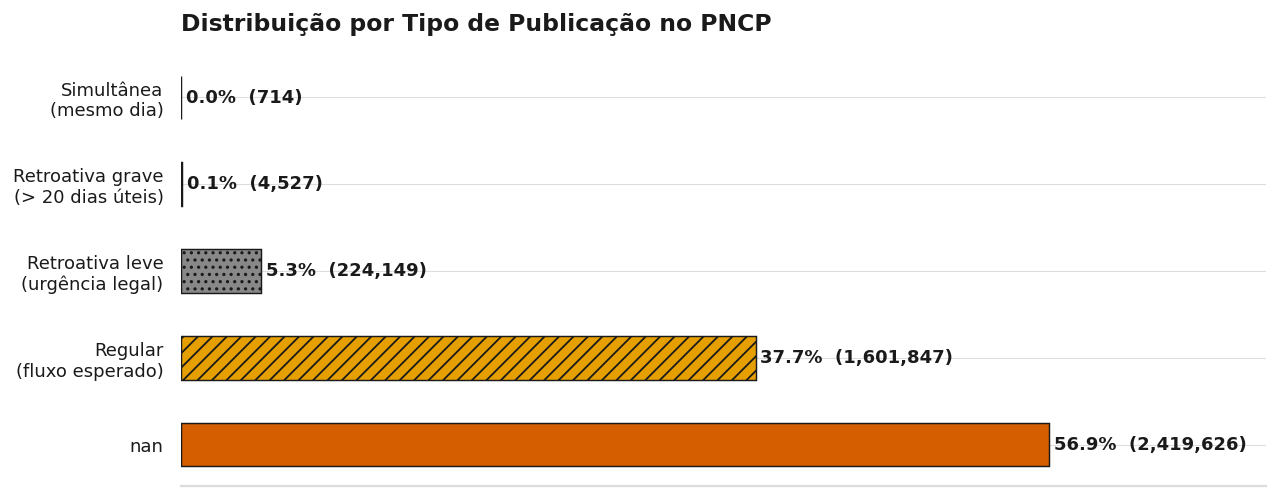

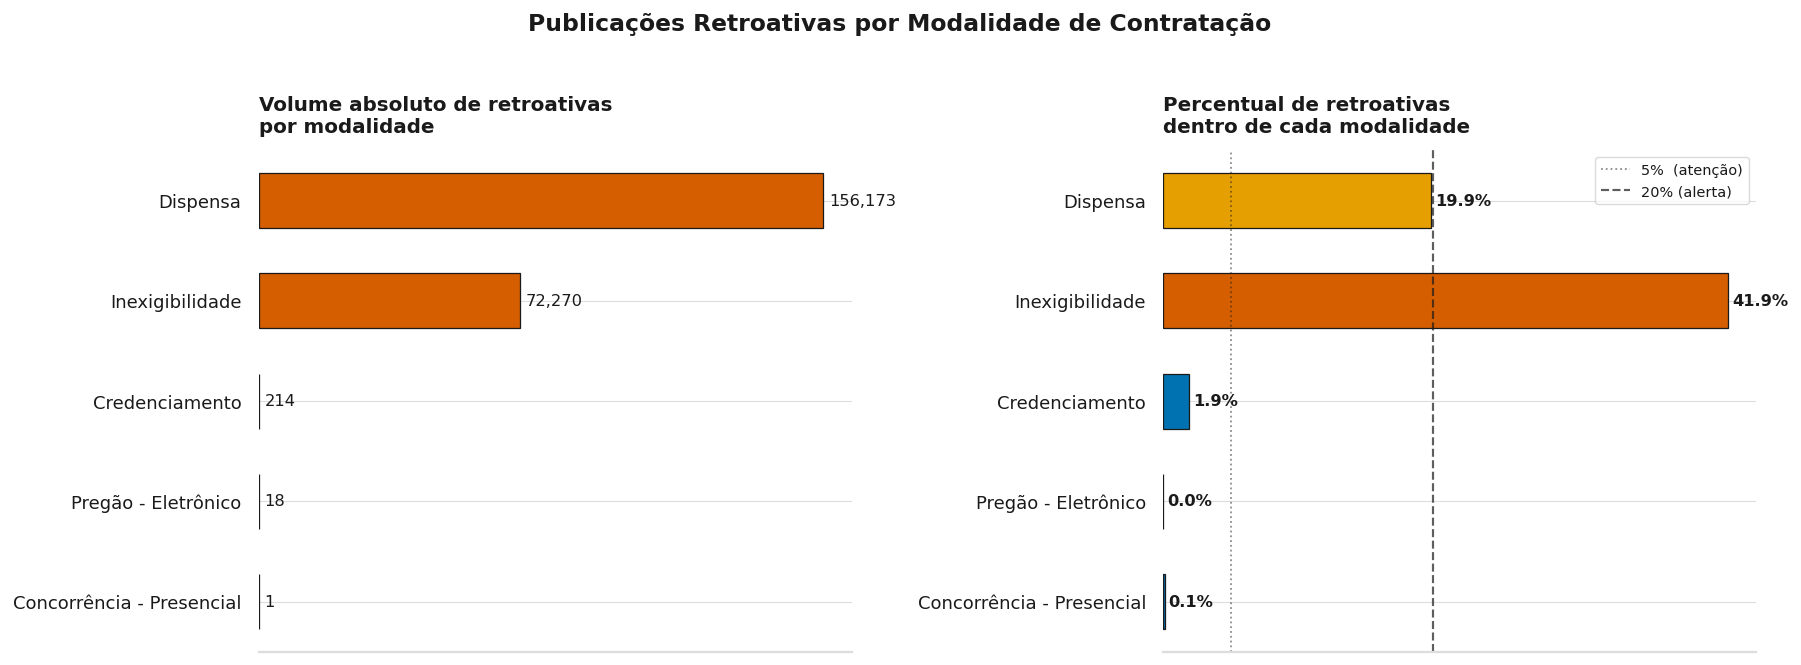

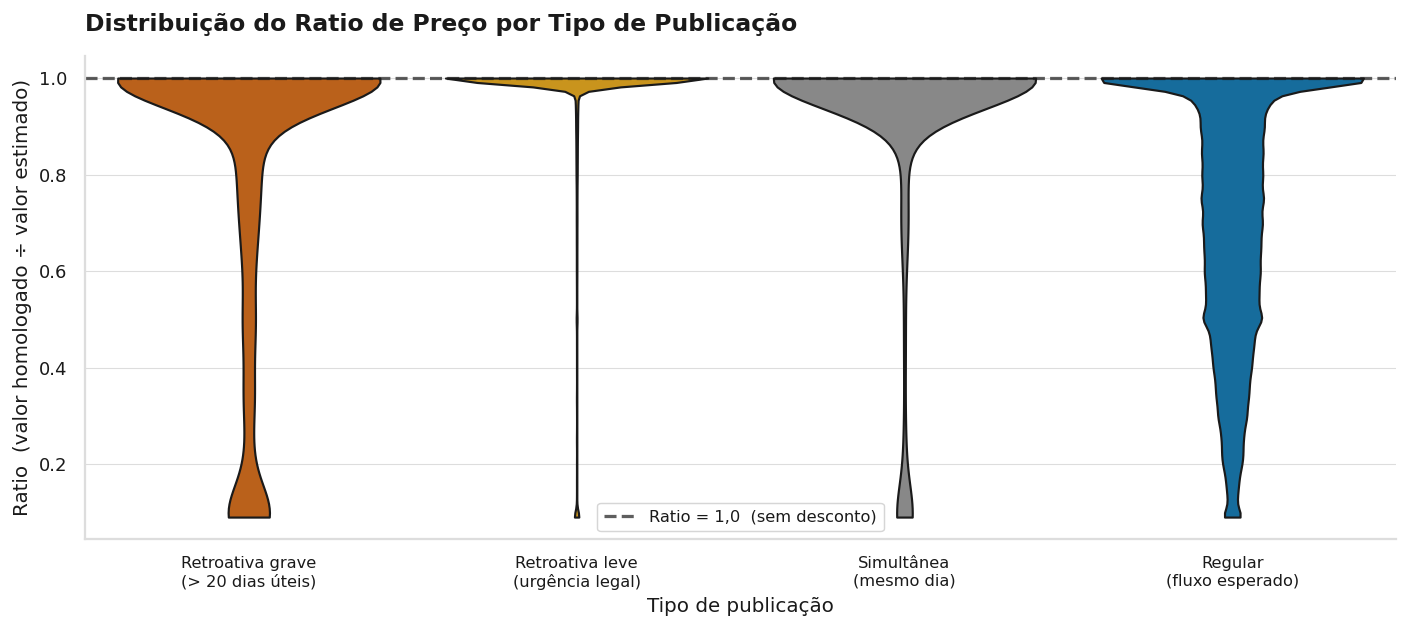

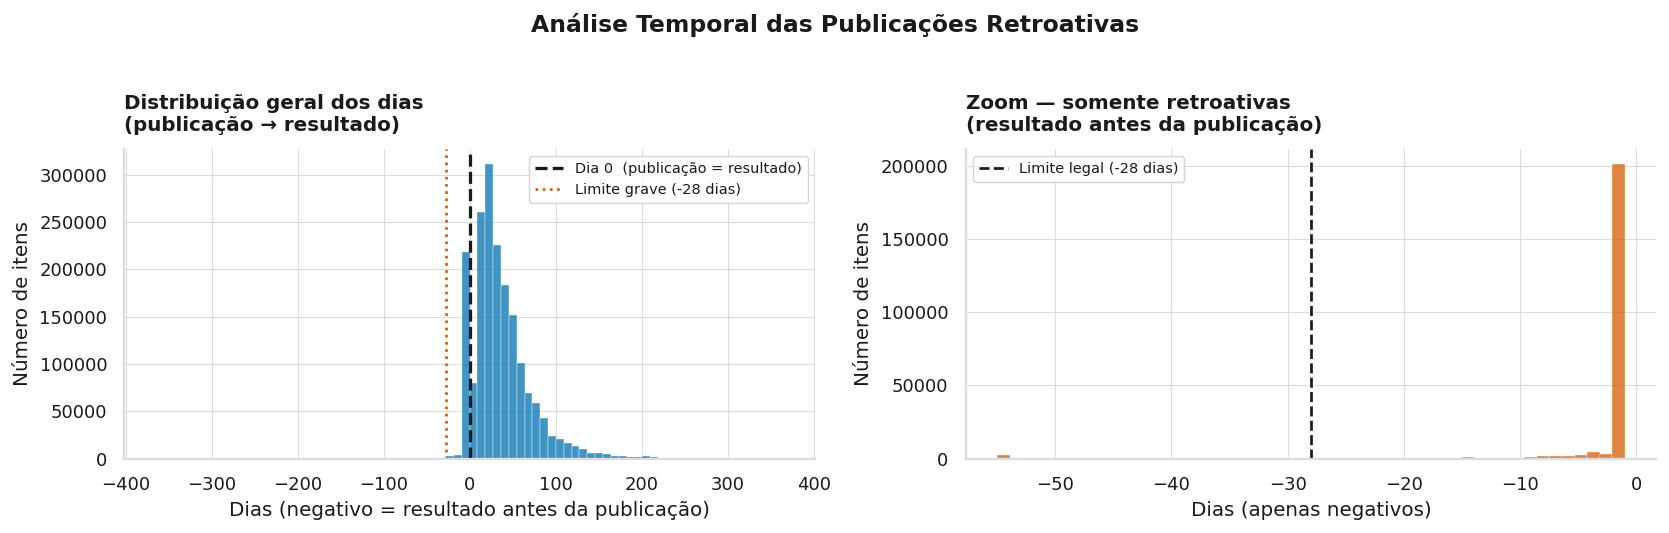


RATIO DE PREÇO POR TIPO DE PUBLICAÇÃO
                                         count    mean     std     min     25%     50%     75%  max
tipo_publicacao                                                                                    
Retroativa grave\n(> 20 dias úteis)     4526.0  0.8201  0.3071  0.0901  0.7653  1.0000  1.0000  1.0
Retroativa leve\n(urgência legal)     224139.0  0.9667  0.1435  0.0901  1.0000  1.0000  1.0000  1.0
Simultânea\n(mesmo dia)                  713.0  0.9245  0.2209  0.0901  1.0000  1.0000  1.0000  1.0
Regular\n(fluxo esperado)            1588834.0  0.7045  0.2517  0.0901  0.5143  0.7421  0.9474  1.0

DECISÃO SUGERIDA PARA O PIPELINE PRINCIPAL
  Retroativas graves : 4,527  (0.11% do total)

  ✅ Volume baixo — flag binária original é suficiente para o modelo.
     A classificação em 4 grupos pode ser usada apenas na EDA.


In [14]:
# %% [markdown]
# ## 8.X Análise de Publicações Retroativas
#
# Investiga o fenômeno de resultados registrados antes da publicação no PNCP.
# Baseado na Lei nº 14.133/2021:
#   - Fluxo regular : publicação → disputa → resultado  (dias >= 0)
#   - Urgência legal: resultado → publicação (até 10-20 dias úteis)  (dias < 0, legítimo)
#   - Alerta        : retroativa em modalidades com rito completo (ex: Pregão)
#
# Este módulo é exploratório — não altera df_base nem df_eda.

# %%
import warnings
warnings.filterwarnings("ignore")

# ── Cópia isolada para não contaminar o pipeline principal ─────────────────
df_retro = df_eda.copy()

# ── Verificação de colunas necessárias ─────────────────────────────────────
COLS_NECESSARIAS = {"data_publicacao_pncp", "data_resultado", "modalidade_nome"}
faltando = COLS_NECESSARIAS - set(df_retro.columns)
if faltando:
    raise ValueError(f"Colunas ausentes no df_eda: {faltando}")

# Garante tipo datetime
for col in ["data_publicacao_pncp", "data_resultado"]:
    df_retro[col] = pd.to_datetime(df_retro[col], errors="coerce")

# ── Recalcula dias (garante consistência mesmo se vier do parquet) ──────────
df_retro["dias_pub_resultado"] = (
    df_retro["data_resultado"] - df_retro["data_publicacao_pncp"]
).dt.days

# ── Classificação em 4 grupos ──────────────────────────────────────────────
#
#  Retroativa grave  : resultado muito antes da publicação (< -20 dias úteis ≈ -28 dias corridos)
#  Retroativa leve   : resultado levemente antes (-28 a -1 dias) — pode ser urgência legal
#  Simultânea        : mesmo dia (0)
#  Regular           : publicação antes do resultado (> 0)

LIMITE_GRAVE = -28   # ~20 dias úteis corridos — prazo máximo legal para publicação

df_retro["tipo_publicacao"] = pd.cut(
    df_retro["dias_pub_resultado"],
    bins=[-np.inf, LIMITE_GRAVE, -1, 0, np.inf],
    labels=[
        "Retroativa grave\n(> 20 dias úteis)",
        "Retroativa leve\n(urgência legal)",
        "Simultânea\n(mesmo dia)",
        "Regular\n(fluxo esperado)",
    ],
    right=True,
)

# ── Resumo numérico ────────────────────────────────────────────────────────
print("=" * 60)
print("RESUMO — DISTRIBUIÇÃO POR TIPO DE PUBLICAÇÃO")
print("=" * 60)
resumo = (
    df_retro["tipo_publicacao"]
    .value_counts(dropna=False)
    .rename("contagem")
    .to_frame()
)
resumo["percentual"] = (resumo["contagem"] / len(df_retro) * 100).round(2)
print(resumo.to_string())

print(f"\nDias mínimo : {df_retro['dias_pub_resultado'].min():,.0f}")
print(f"Dias máximo : {df_retro['dias_pub_resultado'].max():,.0f}")
print(f"Dias mediana: {df_retro['dias_pub_resultado'].median():,.0f}")

# ── Plot 1 — Distribuição dos tipos de publicação ──────────────────────────
PALETA_4 = [VERMELHO_OI, LARANJA_OI, CINZA_MED if "CINZA_MED" in dir() else "#888888", AZUL_OI]

fig, ax = plt.subplots(figsize=(10, 4))
dados_plot = resumo.reset_index()
dados_plot.columns = ["Tipo", "Contagem", "Percentual"]
dados_plot["Tipo"] = dados_plot["Tipo"].astype(str)  # ← adicionar essa linha

bars = ax.barh(
    dados_plot["Tipo"], dados_plot["Percentual"],
    color=PALETA_4,
    edgecolor=CINZA_TEXT if "CINZA_TEXT" in dir() else "#1A1A1A",
    linewidth=0.8,
    height=0.5,
)
for i, bar in enumerate(bars):
    bar.set_hatch(HATCHES[i] if "HATCHES" in dir() else "")
    val = dados_plot["Percentual"].iloc[i]
    cnt = dados_plot["Contagem"].iloc[i]
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%  ({cnt:,.0f})",
        va="center", fontsize=10, fontweight="bold",
        color=CINZA_TEXT if "CINZA_TEXT" in dir() else "#1A1A1A",
    )

ax.set_xlim(0, dados_plot["Percentual"].max() * 1.25)
ax.xaxis.set_visible(False)
ax.set_title(
    "Distribuição por Tipo de Publicação no PNCP",
    loc="left", fontsize=13, fontweight="bold", pad=14,
)
ax.set_xlabel("Percentual dos resultados (%)")
ax.set_ylabel("")
sns.despine(left=True)
plt.tight_layout()
salvar_ou_mostrar(fig)


# ── Plot 2 — Retroativas por modalidade (alerta de irregularidade) ──────────
#
# Modalidades com rito completo NÃO deveriam ter retroativas graves.
# Se Pregão Eletrônico aparecer com alto percentual → sinal de alerta.

df_alerta = df_retro[
    df_retro["tipo_publicacao"].isin([
        "Retroativa grave\n(> 20 dias úteis)",
        "Retroativa leve\n(urgência legal)",
    ])
].copy()

if "modalidade_nome" in df_alerta.columns and len(df_alerta) > 0:
    cross = (
        df_alerta.groupby("modalidade_nome", observed=True)["tipo_publicacao"]
        .value_counts(normalize=False)
        .unstack(fill_value=0)
        .reset_index()
    )
    cross["total_retro"] = cross.iloc[:, 1:].sum(axis=1)
    cross = cross.sort_values("total_retro", ascending=True).tail(10)

    # percentual de retroativas dentro de cada modalidade
    total_por_modalidade = df_retro["modalidade_nome"].value_counts()
    cross["pct_retro"] = (
        cross["total_retro"] /
        cross["modalidade_nome"].map(total_por_modalidade) * 100
    ).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # volume absoluto
    ax1 = axes[0]
    ax1.barh(
        cross["modalidade_nome"], cross["total_retro"],
        color=VERMELHO_OI if "VERMELHO_OI" in dir() else "#D55E00",
        edgecolor="#1A1A1A", linewidth=0.7, height=0.55,
    )
    for bar, val in zip(ax1.patches, cross["total_retro"]):
        ax1.text(
            bar.get_width() + cross["total_retro"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9,
        )
    ax1.set_title("Volume absoluto de retroativas\npor modalidade",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax1.set_xlabel("Número de resultados retroativos")
    sns.despine(ax=ax1, left=True)
    ax1.xaxis.set_visible(False)

    # percentual dentro de cada modalidade — mais revelador
    ax2 = axes[1]
    cores_pct = [
        VERMELHO_OI if pct > 20 else (LARANJA_OI if pct > 5 else AZUL_OI)
        for pct in cross["pct_retro"]
    ] if "VERMELHO_OI" in dir() else ["#0072B2"] * len(cross)

    ax2.barh(
        cross["modalidade_nome"], cross["pct_retro"],
        color=cores_pct,
        edgecolor="#1A1A1A", linewidth=0.7, height=0.55,
    )
    # linha de referência: 5% e 20%
    ax2.axvline(5,  color="#1A1A1A", linewidth=1.0, linestyle=":",  alpha=0.5, label="5%  (atenção)")
    ax2.axvline(20, color="#1A1A1A", linewidth=1.2, linestyle="--", alpha=0.7, label="20% (alerta)")
    ax2.legend(fontsize=8, framealpha=0.7)
    for bar, val in zip(ax2.patches, cross["pct_retro"]):
        ax2.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9, fontweight="bold",
        )
    ax2.set_title("Percentual de retroativas\ndentro de cada modalidade",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax2.set_xlabel("% de resultados retroativos na modalidade")
    sns.despine(ax=ax2, left=True)
    ax2.xaxis.set_visible(False)

    plt.suptitle(
        "Publicações Retroativas por Modalidade de Contratação",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ── Plot 3 — Ratio de preço: regular vs retroativa ─────────────────────────
#
# Verifica se publicações retroativas estão associadas a preços piores.

if "ratio_preco_total_wins" in df_retro.columns:
    df_violin = df_retro[
        df_retro["tipo_publicacao"].notna() &
        df_retro["ratio_preco_total_wins"].notna()
    ].copy()

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.violinplot(
        data=df_violin,
        x="tipo_publicacao",
        y="ratio_preco_total_wins",
        hue="tipo_publicacao",
        palette=PALETA_4 if "PALETA_4" in dir() else "Set2",
        cut=0,
        inner=None,
        legend=False,
        linewidth=1.2,
        linecolor="#1A1A1A",
        ax=ax,
    )
    ax.axhline(1.0, color="#1A1A1A", linewidth=1.8, linestyle="--", alpha=0.7,
               label="Ratio = 1,0  (sem desconto)")
    ax.legend(fontsize=9, framealpha=0.8)
    ax.set_title(
        "Distribuição do Ratio de Preço por Tipo de Publicação",
        loc="left", fontsize=13, fontweight="bold", pad=14,
    )
    ax.set_xlabel("Tipo de publicação")
    ax.set_ylabel("Ratio  (valor homologado ÷ valor estimado)")
    ax.tick_params(axis="x", labelsize=9)
    sns.despine()
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ── Plot 4 — Distribuição dos dias (zoom nas retroativas) ──────────────────
df_neg = df_retro[df_retro["dias_pub_resultado"] < 0]["dias_pub_resultado"]

if len(df_neg) > 0:
    p01 = df_neg.quantile(0.01)   # corta extremos para legibilidade

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # histograma geral
    ax1 = axes[0]
    sns.histplot(
        df_retro["dias_pub_resultado"].clip(-365, 365),
        bins=80, color=AZUL_OI if "AZUL_OI" in dir() else "#0072B2",
        edgecolor="white", linewidth=0.2, ax=ax1,
    )
    ax1.axvline(0, color="#1A1A1A", linewidth=1.8, linestyle="--",
                label="Dia 0  (publicação = resultado)")
    ax1.axvline(LIMITE_GRAVE, color=VERMELHO_OI if "VERMELHO_OI" in dir() else "red",
                linewidth=1.5, linestyle=":", label=f"Limite grave ({LIMITE_GRAVE} dias)")
    ax1.legend(fontsize=8)
    ax1.set_title("Distribuição geral dos dias\n(publicação → resultado)",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax1.set_xlabel("Dias (negativo = resultado antes da publicação)")
    ax1.set_ylabel("Número de itens")
    sns.despine(ax=ax1)

    # zoom: apenas retroativas
    ax2 = axes[1]
    sns.histplot(
        df_neg.clip(lower=p01),
        bins=50,
        color=VERMELHO_OI if "VERMELHO_OI" in dir() else "red",
        edgecolor="white", linewidth=0.2, ax=ax2,
    )
    ax2.axvline(LIMITE_GRAVE, color="#1A1A1A", linewidth=1.5, linestyle="--",
                label=f"Limite legal ({LIMITE_GRAVE} dias)")
    ax2.legend(fontsize=8)
    ax2.set_title("Zoom — somente retroativas\n(resultado antes da publicação)",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax2.set_xlabel("Dias (apenas negativos)")
    ax2.set_ylabel("Número de itens")
    sns.despine(ax=ax2)

    plt.suptitle(
        "Análise Temporal das Publicações Retroativas",
        fontsize=13, fontweight="bold", y=1.02,
    )
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ── Resumo estatístico por grupo ───────────────────────────────────────────
print("\n" + "=" * 60)
print("RATIO DE PREÇO POR TIPO DE PUBLICAÇÃO")
print("=" * 60)
if "ratio_preco_total_wins" in df_retro.columns:
    print(
        df_retro.groupby("tipo_publicacao", observed=True)["ratio_preco_total_wins"]
        .describe(percentiles=[.25, .5, .75])
        .round(4)
        .to_string()
    )

print("\n" + "=" * 60)
print("DECISÃO SUGERIDA PARA O PIPELINE PRINCIPAL")
print("=" * 60)
n_grave = (df_retro["tipo_publicacao"] == "Retroativa grave\n(> 20 dias úteis)").sum()
pct_grave = n_grave / len(df_retro) * 100
print(f"  Retroativas graves : {n_grave:,.0f}  ({pct_grave:.2f}% do total)")
print()
if pct_grave > 5:
    print("  ⚠️  Volume significativo — recomendado incluir 'tipo_publicacao'")
    print("     como feature no modelo E investigar as modalidades com > 20%.")
else:
    print("  ✅ Volume baixo — flag binária original é suficiente para o modelo.")
    print("     A classificação em 4 grupos pode ser usada apenas na EDA.")

Total df_eda          :  4,250,863
Com ambas as datas    :  1,831,237
Sem resultado (exclui):  2,324,511
Percentual mantido    : 43.1%



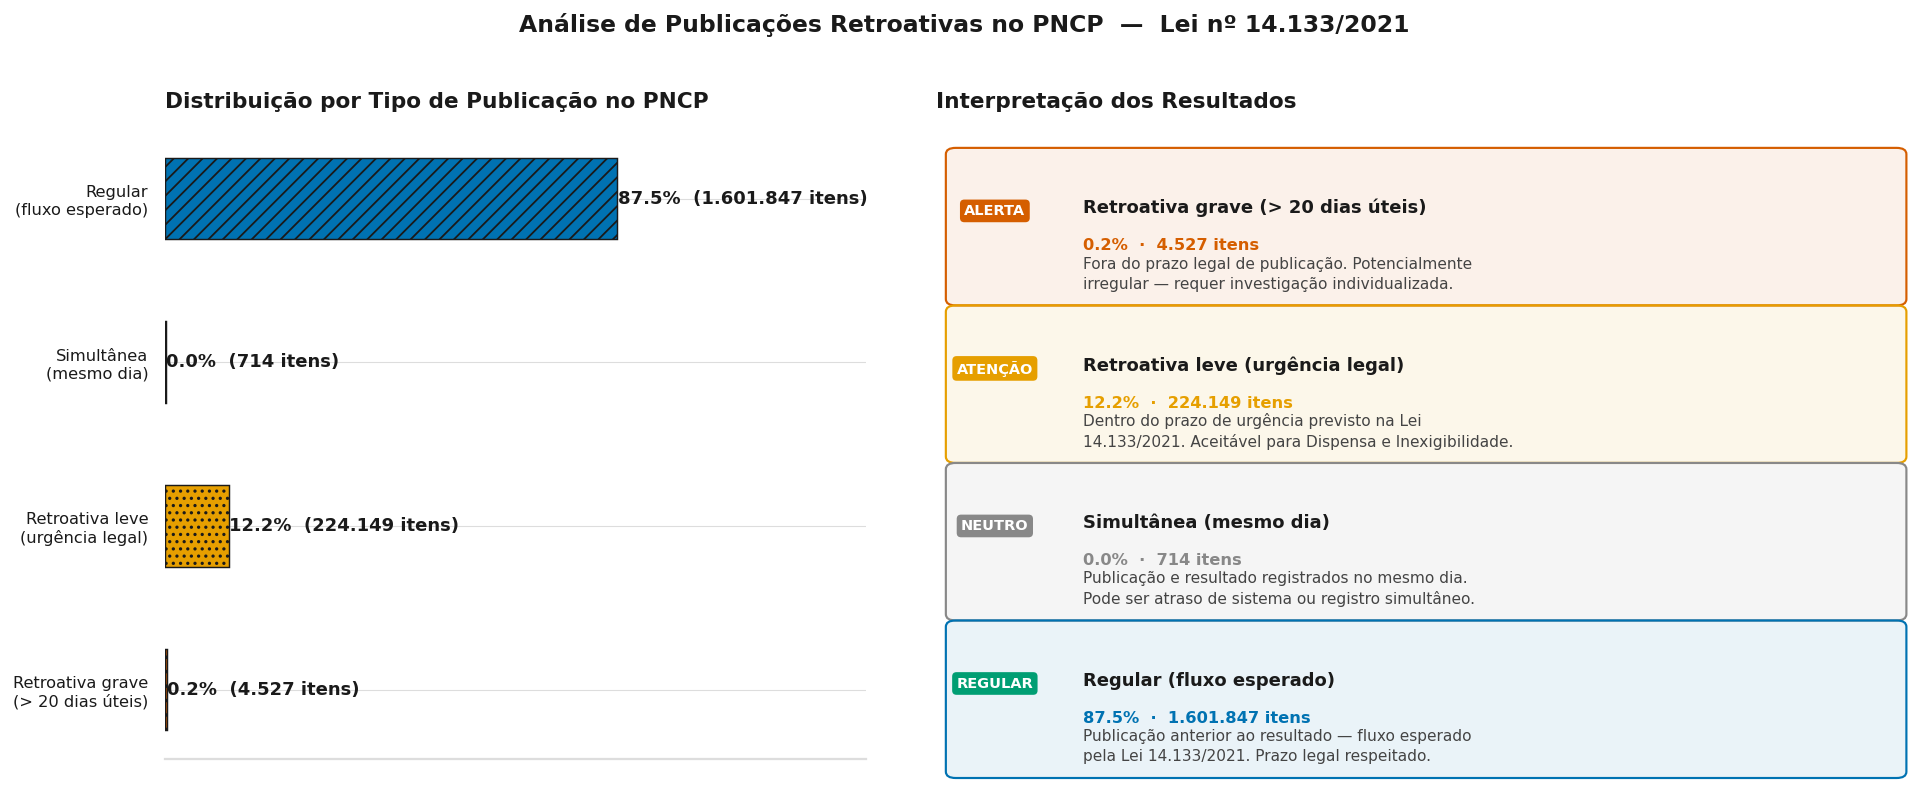

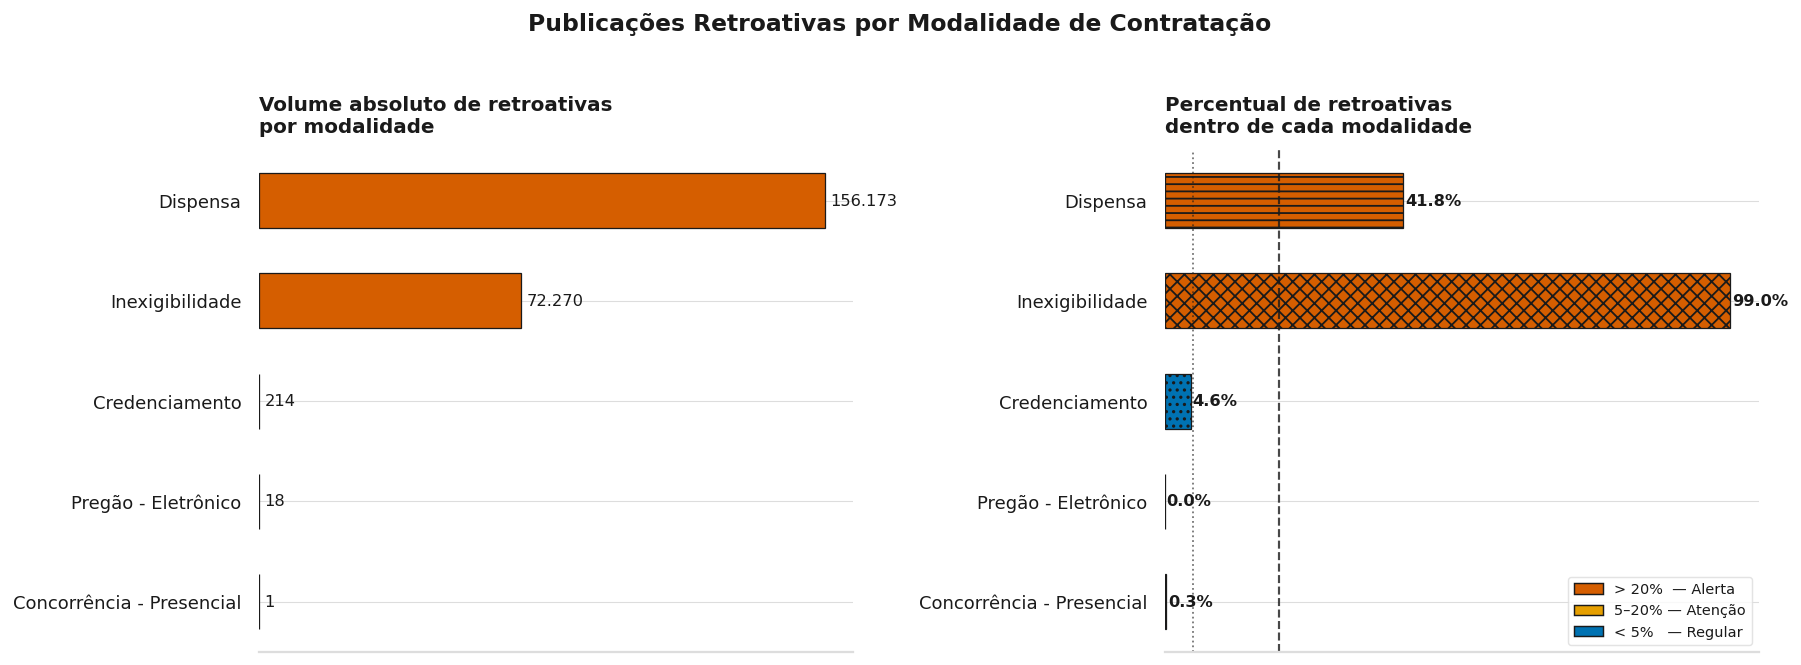

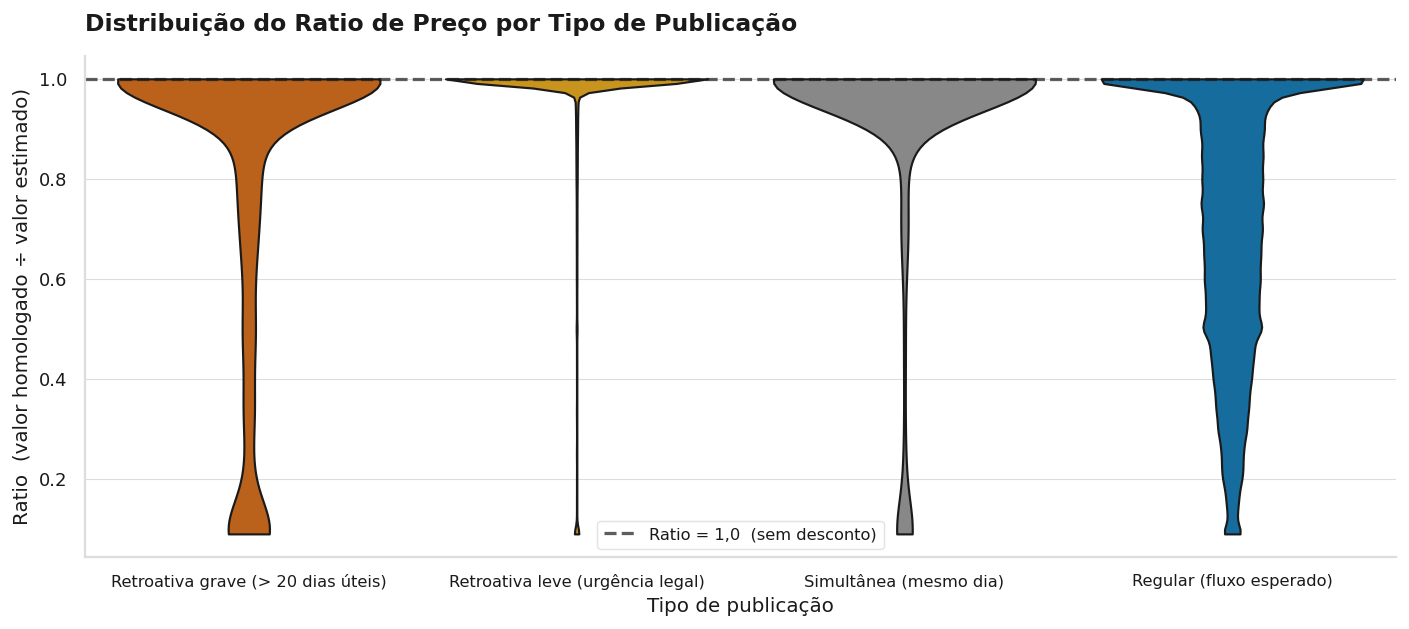

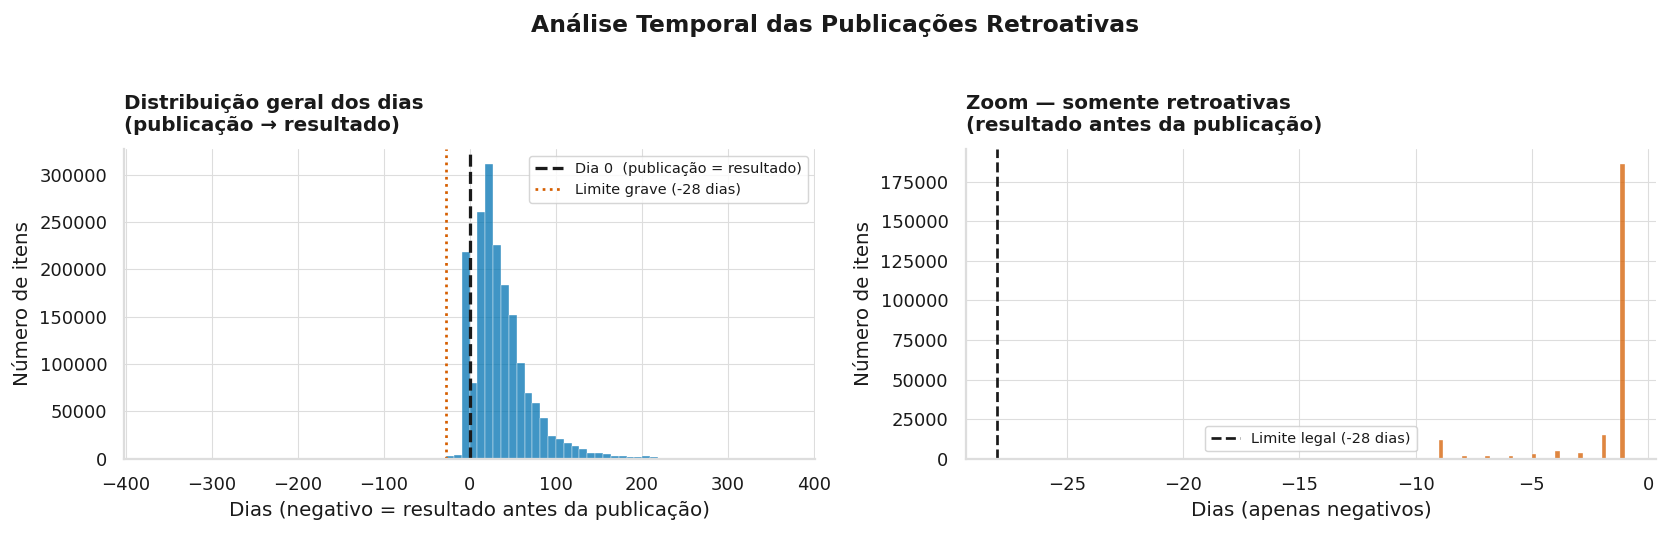

RESUMO INTERPRETATIVO

  [ALERTA] Retroativa grave (> 20 dias úteis)
  0.2%  ·  4.527 itens
  → Fora do prazo legal de publicação. Potencialmente irregular — requer investigação individualizada.

  [ATENÇÃO] Retroativa leve (urgência legal)
  12.2%  ·  224.149 itens
  → Dentro do prazo de urgência previsto na Lei 14.133/2021. Aceitável para Dispensa e Inexigibilidade.

  [NEUTRO] Simultânea (mesmo dia)
  0.0%  ·  714 itens
  → Publicação e resultado registrados no mesmo dia. Pode ser atraso de sistema ou registro simultâneo.

  [REGULAR] Regular (fluxo esperado)
  87.5%  ·  1.601.847 itens
  → Publicação anterior ao resultado — fluxo esperado pela Lei 14.133/2021. Prazo legal respeitado.

DECISÃO PARA O PIPELINE PRINCIPAL

  Retroativas graves : 4,527  (0.25% do total com resultado)

  ✅ Volume baixo — flag binária original é suficiente para o modelo.
     Classificação em 4 grupos: usar apenas na EDA e interpretação.


In [16]:
# %% [markdown]
# ## 8.X Análise de Publicações Retroativas — com tabela interpretativa

# %%
import warnings
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
warnings.filterwarnings("ignore")

# ── Cópia isolada — apenas itens COM resultado e COM data de publicação ─────
df_retro = df_eda[
    df_eda["data_resultado"].notna() &
    df_eda["data_publicacao_pncp"].notna()
].copy()

print(f"Total df_eda          : {len(df_eda):>10,.0f}")
print(f"Com ambas as datas    : {len(df_retro):>10,.0f}")
print(f"Sem resultado (exclui): {df_eda['data_resultado'].isna().sum():>10,.0f}")
print(f"Percentual mantido    : {len(df_retro)/len(df_eda)*100:.1f}%\n")

# ── Verificação de colunas ─────────────────────────────────────────────────
COLS_NECESSARIAS = {"data_publicacao_pncp", "data_resultado", "modalidade_nome"}
faltando = COLS_NECESSARIAS - set(df_retro.columns)
if faltando:
    raise ValueError(f"Colunas ausentes: {faltando}")

for col in ["data_publicacao_pncp", "data_resultado"]:
    df_retro[col] = pd.to_datetime(df_retro[col], errors="coerce")

df_retro["dias_pub_resultado"] = (
    df_retro["data_resultado"] - df_retro["data_publicacao_pncp"]
).dt.days

# ── Classificação ──────────────────────────────────────────────────────────
LIMITE_GRAVE = -28

ORDEM = [
    "Retroativa grave\n(> 20 dias úteis)",
    "Retroativa leve\n(urgência legal)",
    "Simultânea\n(mesmo dia)",
    "Regular\n(fluxo esperado)",
]

df_retro["tipo_publicacao"] = pd.Categorical(
    pd.cut(
        df_retro["dias_pub_resultado"],
        bins=[-np.inf, LIMITE_GRAVE, -1, 0, np.inf],
        labels=ORDEM,
    ),
    categories=ORDEM,
    ordered=True,
)

# ── Resumo numérico ────────────────────────────────────────────────────────
resumo = (
    df_retro["tipo_publicacao"]
    .value_counts(dropna=True)
    .reindex(ORDEM)
    .rename("contagem")
    .to_frame()
)
resumo["percentual"] = (resumo["contagem"] / len(df_retro) * 100).round(2)
resumo = resumo.reset_index()
resumo.columns = ["Tipo", "Contagem", "Percentual"]
resumo["Tipo_str"] = resumo["Tipo"].astype(str)

# ── Configurações de cor e interpretação ───────────────────────────────────
CONFIG = {
    "Retroativa grave\n(> 20 dias úteis)": {
        "cor":        VERMELHO_OI,
        "hatch":      "xxx",
        "icone":      "⚠️",
        "status":     "ALERTA",
        "cor_status": VERMELHO_OI,
        "interpretacao": "Fora do prazo legal de publicação. Potencialmente\nirregular — requer investigação individualizada.",
    },
    "Retroativa leve\n(urgência legal)": {
        "cor":        LARANJA_OI,
        "hatch":      "...",
        "icone":      "⚡",
        "status":     "ATENÇÃO",
        "cor_status": LARANJA_OI,
        "interpretacao": "Dentro do prazo de urgência previsto na Lei\n14.133/2021. Aceitável para Dispensa e Inexigibilidade.",
    },
    "Simultânea\n(mesmo dia)": {
        "cor":        "#888888",
        "hatch":      "",
        "icone":      "↔",
        "status":     "NEUTRO",
        "cor_status": "#888888",
        "interpretacao": "Publicação e resultado registrados no mesmo dia.\nPode ser atraso de sistema ou registro simultâneo.",
    },
    "Regular\n(fluxo esperado)": {
        "cor":        AZUL_OI,
        "hatch":      "///",
        "icone":      "✅",
        "status":     "REGULAR",
        "cor_status": VERDE_OI,
        "interpretacao": "Publicação anterior ao resultado — fluxo esperado\npela Lei 14.133/2021. Prazo legal respeitado.",
    },
}

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Distribuição dos tipos + tabela interpretativa
# ══════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(15, 6), facecolor=FUNDO)
gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4], figure=fig)

ax_bar   = fig.add_subplot(gs[0])
ax_tabela = fig.add_subplot(gs[1])
ax_tabela.axis("off")

# ── Gráfico de barras ──────────────────────────────────────────────────────
cores  = [CONFIG[t]["cor"]   for t in resumo["Tipo_str"]]
hatches = [CONFIG[t]["hatch"] for t in resumo["Tipo_str"]]

bars = ax_bar.barh(
    resumo["Tipo_str"], resumo["Percentual"],
    color=cores, edgecolor=CINZA_TEXT, linewidth=0.8, height=0.5,
)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
    bar.set_edgecolor(CINZA_TEXT)

for i, (bar, row) in enumerate(zip(bars, resumo.itertuples())):
    cnt_fmt = f"{row.Contagem:,.0f}".replace(",", ".")
    ax_bar.text(
        max(bar.get_width(), 0.05) + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{row.Percentual:.1f}%  ({cnt_fmt} itens)",
        va="center", fontsize=10, fontweight="bold", color=CINZA_TEXT,
    )

ax_bar.set_xlim(0, resumo["Percentual"].max() * 1.55)
ax_bar.xaxis.set_visible(False)
ax_bar.set_title(
    "Distribuição por Tipo de Publicação no PNCP",
    loc="left", fontsize=12, fontweight="bold", pad=12,
)
ax_bar.set_ylabel("")
ax_bar.tick_params(axis="y", labelsize=9)
sns.despine(ax=ax_bar, left=True)

# ── Tabela interpretativa ──────────────────────────────────────────────────
n    = len(resumo)
y0   = 0.97
dy   = 1.0 / n
pad  = 0.02

for i, row in enumerate(resumo.itertuples()):
    cfg    = CONFIG[row.Tipo_str]
    y_top  = y0 - i * dy
    y_mid  = y_top - dy / 2
    cnt_fmt = f"{row.Contagem:,.0f}".replace(",", ".")

    # caixa de fundo
    fancy = FancyBboxPatch(
        (pad, y_top - dy + pad * 0.5),
        1 - 2 * pad, dy - pad,
        boxstyle="round,pad=0.01",
        linewidth=1.2,
        edgecolor=cfg["cor"],
        facecolor=cfg["cor"] + "15",   # cor com 15% opacidade (hex alpha)
        transform=ax_tabela.transAxes,
        clip_on=False,
    )
    ax_tabela.add_patch(fancy)

    # badge de status
    ax_tabela.text(
        0.06, y_mid + 0.025,
        cfg["status"],
        transform=ax_tabela.transAxes,
        fontsize=8, fontweight="bold",
        color="white",
        ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor=cfg["cor_status"],
            edgecolor="none",
        ),
    )

    # nome do tipo
    tipo_limpo = row.Tipo_str.replace("\n", " ")
    ax_tabela.text(
        0.15, y_mid + 0.03,
        tipo_limpo,
        transform=ax_tabela.transAxes,
        fontsize=10, fontweight="bold", color=CINZA_TEXT,
        va="center",
    )

    # percentual + contagem
    ax_tabela.text(
        0.15, y_mid - 0.03,
        f"{row.Percentual:.1f}%  ·  {cnt_fmt} itens",
        transform=ax_tabela.transAxes,
        fontsize=9, color=cfg["cor"], fontweight="bold",
        va="center",
    )

    # interpretação
    ax_tabela.text(
        0.15, y_mid - 0.075,
        cfg["interpretacao"],
        transform=ax_tabela.transAxes,
        fontsize=8.5, color="#444444",
        va="center", linespacing=1.4,
    )

ax_tabela.set_title(
    "Interpretação dos Resultados",
    loc="left", fontsize=12, fontweight="bold", pad=12,
    color=CINZA_TEXT,
)

plt.suptitle(
    "Análise de Publicações Retroativas no PNCP  —  Lei nº 14.133/2021",
    fontsize=13, fontweight="bold", y=1.01, color=CINZA_TEXT,
)
plt.tight_layout(rect=[0, 0, 1, 1])
salvar_ou_mostrar(fig)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Retroativas por modalidade (volume + percentual)
# ══════════════════════════════════════════════════════════════════════════════
df_alerta = df_retro[
    df_retro["tipo_publicacao"].isin([
        "Retroativa grave\n(> 20 dias úteis)",
        "Retroativa leve\n(urgência legal)",
    ])
].copy()

if "modalidade_nome" in df_alerta.columns and len(df_alerta) > 0:
    cross = (
        df_alerta.groupby("modalidade_nome", observed=True)["tipo_publicacao"]
        .value_counts(normalize=False)
        .unstack(fill_value=0)
        .reset_index()
    )
    cross["total_retro"] = cross.iloc[:, 1:].sum(axis=1)
    cross = cross.sort_values("total_retro", ascending=True).tail(10)

    total_por_modalidade = df_retro["modalidade_nome"].value_counts()
    cross["pct_retro"] = (
        cross["total_retro"] /
        cross["modalidade_nome"].map(total_por_modalidade) * 100
    ).round(1)

    # cor dinâmica por percentual
    def _cor_pct(pct):
        if pct > 20: return VERMELHO_OI
        if pct > 5:  return LARANJA_OI
        return AZUL_OI

    cores_pct = [_cor_pct(p) for p in cross["pct_retro"]]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=FUNDO)

    ax1 = axes[0]
    bars1 = ax1.barh(
        cross["modalidade_nome"], cross["total_retro"],
        color=VERMELHO_OI, edgecolor=CINZA_TEXT,
        linewidth=0.7, height=0.55,
    )
    for bar, val in zip(bars1, cross["total_retro"]):
        ax1.text(
            bar.get_width() + cross["total_retro"].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}".replace(",", "."),
            va="center", fontsize=9, color=CINZA_TEXT,
        )
    ax1.set_title("Volume absoluto de retroativas\npor modalidade",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax1.xaxis.set_visible(False)
    sns.despine(ax=ax1, left=True)

    ax2 = axes[1]
    bars2 = ax2.barh(
        cross["modalidade_nome"], cross["pct_retro"],
        color=cores_pct, edgecolor=CINZA_TEXT,
        linewidth=0.7, height=0.55,
    )
    for i, bar in enumerate(bars2):
        bar.set_hatch(HATCHES[i % len(HATCHES)])
        bar.set_edgecolor(CINZA_TEXT)

    ax2.axvline(5,  color=CINZA_TEXT, linewidth=1.0, linestyle=":",
                alpha=0.6, label="5%  (atenção)")
    ax2.axvline(20, color=CINZA_TEXT, linewidth=1.2, linestyle="--",
                alpha=0.8, label="20% (alerta)")
    ax2.legend(fontsize=8, framealpha=0.7, edgecolor=CINZA_GRID)

    for bar, val in zip(bars2, cross["pct_retro"]):
        ax2.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=9,
            fontweight="bold", color=CINZA_TEXT,
        )
    ax2.set_title("Percentual de retroativas\ndentro de cada modalidade",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax2.xaxis.set_visible(False)
    sns.despine(ax=ax2, left=True)

    # legenda de cores do percentual
    from matplotlib.patches import Patch
    legenda_cores = [
        Patch(facecolor=VERMELHO_OI, edgecolor=CINZA_TEXT, label="> 20%  — Alerta"),
        Patch(facecolor=LARANJA_OI,  edgecolor=CINZA_TEXT, label="5–20% — Atenção"),
        Patch(facecolor=AZUL_OI,     edgecolor=CINZA_TEXT, label="< 5%   — Regular"),
    ]
    ax2.legend(
        handles=legenda_cores,
        fontsize=8, framealpha=0.8,
        edgecolor=CINZA_GRID, loc="lower right",
    )

    plt.suptitle(
        "Publicações Retroativas por Modalidade de Contratação",
        fontsize=13, fontweight="bold", y=1.02, color=CINZA_TEXT,
    )
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 3 — Violinplot: ratio por tipo de publicação
# ══════════════════════════════════════════════════════════════════════════════
if "ratio_preco_total_wins" in df_retro.columns:
    df_violin = df_retro[
        df_retro["tipo_publicacao"].notna() &
        df_retro["ratio_preco_total_wins"].notna()
    ].copy()
    df_violin["tipo_publicacao"] = pd.Categorical(
        df_violin["tipo_publicacao"].astype(str),
        categories=ORDEM, ordered=True,
    )
    df_violin = df_violin.sort_values("tipo_publicacao")

    cores_violin = [CONFIG[t]["cor"] for t in ORDEM]

    fig, ax = plt.subplots(figsize=(11, 5), facecolor=FUNDO)
    sns.violinplot(
        data=df_violin,
        x="tipo_publicacao",
        y="ratio_preco_total_wins",
        hue="tipo_publicacao",
        palette=cores_violin,
        order=ORDEM,
        cut=0, inner=None, legend=False,
        linewidth=1.2, linecolor=CINZA_TEXT,
        ax=ax,
    )
    ax.axhline(1.0, color=CINZA_TEXT, linewidth=1.8, linestyle="--", alpha=0.7,
               label="Ratio = 1,0  (sem desconto)")
    ax.legend(fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)
    ax.set_title(
        "Distribuição do Ratio de Preço por Tipo de Publicação",
        loc="left", fontsize=13, fontweight="bold", pad=14,
    )
    ax.set_xlabel("Tipo de publicação")
    ax.set_ylabel("Ratio  (valor homologado ÷ valor estimado)")
    ax.set_xticklabels([t.replace("\n", " ") for t in ORDEM], fontsize=9)
    sns.despine(ax=ax)
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 4 — Análise temporal (geral + zoom retroativas)
# ══════════════════════════════════════════════════════════════════════════════
df_neg = df_retro[df_retro["dias_pub_resultado"] < 0]["dias_pub_resultado"]

if len(df_neg) > 0:
    p05 = df_neg.quantile(0.05)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), facecolor=FUNDO)

    ax1 = axes[0]
    sns.histplot(
        df_retro["dias_pub_resultado"].clip(-365, 365),
        bins=80, color=AZUL_OI, edgecolor="white", linewidth=0.2, ax=ax1,
    )
    ax1.axvline(0, color=CINZA_TEXT, linewidth=1.8, linestyle="--",
                label="Dia 0  (publicação = resultado)")
    ax1.axvline(LIMITE_GRAVE, color=VERMELHO_OI, linewidth=1.5, linestyle=":",
                label=f"Limite grave ({LIMITE_GRAVE} dias)")
    ax1.legend(fontsize=8, framealpha=0.8)
    ax1.set_title("Distribuição geral dos dias\n(publicação → resultado)",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax1.set_xlabel("Dias (negativo = resultado antes da publicação)")
    ax1.set_ylabel("Número de itens")
    sns.despine(ax=ax1)

    ax2 = axes[1]
    sns.histplot(
        df_neg.clip(lower=p05),
        bins=40, color=VERMELHO_OI, edgecolor="white", linewidth=0.2, ax=ax2,
    )
    ax2.axvline(LIMITE_GRAVE, color=CINZA_TEXT, linewidth=1.5, linestyle="--",
                label=f"Limite legal ({LIMITE_GRAVE} dias)")
    ax2.legend(fontsize=8, framealpha=0.8)
    ax2.set_title("Zoom — somente retroativas\n(resultado antes da publicação)",
                  loc="left", fontsize=11, fontweight="bold", pad=10)
    ax2.set_xlabel("Dias (apenas negativos)")
    ax2.set_ylabel("Número de itens")
    sns.despine(ax=ax2)

    plt.suptitle("Análise Temporal das Publicações Retroativas",
                 fontsize=13, fontweight="bold", y=1.02, color=CINZA_TEXT)
    plt.tight_layout()
    salvar_ou_mostrar(fig)


# ══════════════════════════════════════════════════════════════════════════════
# RESUMO FINAL — decisão para o pipeline
# ══════════════════════════════════════════════════════════════════════════════
print("=" * 60)
print("RESUMO INTERPRETATIVO")
print("=" * 60)
for _, row in resumo.iterrows():
    cfg     = CONFIG[row["Tipo_str"]]
    cnt_fmt = f"{row['Contagem']:,.0f}".replace(",", ".")
    interp  = cfg["interpretacao"].replace("\n", " ")
    print(f"\n  [{cfg['status']}] {row['Tipo_str'].replace(chr(10), ' ')}")
    print(f"  {row['Percentual']:.1f}%  ·  {cnt_fmt} itens")
    print(f"  → {interp}")

print("\n" + "=" * 60)
print("DECISÃO PARA O PIPELINE PRINCIPAL")
print("=" * 60)
n_grave  = resumo[resumo["Tipo_str"].str.startswith("Retroativa grave")]["Contagem"].sum()
pct_grave = n_grave / len(df_retro) * 100
print(f"\n  Retroativas graves : {n_grave:,.0f}  ({pct_grave:.2f}% do total com resultado)")
if pct_grave > 5:
    print("\n  ⚠️  Volume significativo — incluir 'tipo_publicacao' como feature.")
else:
    print("\n  ✅ Volume baixo — flag binária original é suficiente para o modelo.")
    print("     Classificação em 4 grupos: usar apenas na EDA e interpretação.")

9. Análise Temporal

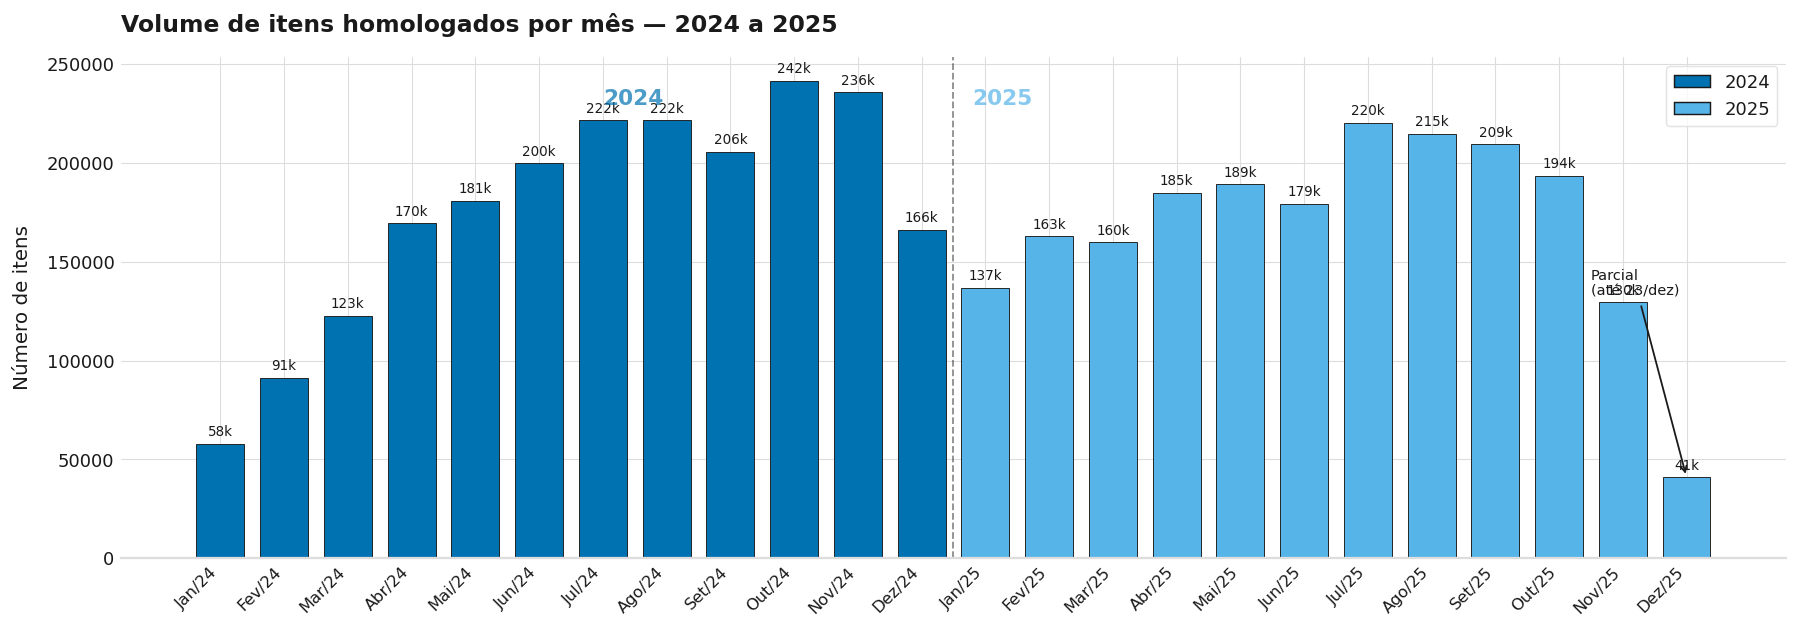

In [24]:
# ── 9.1 Volume de itens por mês — 2024 a 2025 ───────────────────────────────
#
# Usa data_publicacao_pncp (2,6% de nulos) como âncora temporal.
# data_resultado só cobre até dez/2024 — não cobre 2025.
# Dez/2025 é parcial: base extraída até 23/12/2025.

MESES_PT = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

df_vol = df_eda.copy()
df_vol['data_pub'] = pd.to_datetime(df_vol['data_publicacao_pncp'], errors='coerce')
df_vol = df_vol[
    df_vol['data_pub'].dt.year.isin([2024, 2025]) &
    df_vol['data_pub'].notna()
].copy()

mensal = (
    df_vol.groupby(df_vol['data_pub'].dt.to_period('M'))
    .size()
    .reset_index(name='n_itens')
)
mensal['ano'] = mensal['data_pub'].dt.year
mensal['mes'] = mensal['data_pub'].dt.month
mensal['mes_label'] = [
    f"{MESES_PT[m]}/{str(a)[2:]}" for m, a in zip(mensal['mes'], mensal['ano'])
]

CORES_ANO = {2024: AZUL_OI, 2025: CIANO_OI}
cores = [CORES_ANO[a] for a in mensal['ano']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    range(len(mensal)), mensal['n_itens'],
    color=cores, edgecolor=CINZA_TEXT, linewidth=0.5, width=0.75,
)

for bar, val in zip(bars, mensal['n_itens']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + mensal['n_itens'].max() * 0.01,
        f"{val/1000:.0f}k",
        ha='center', va='bottom', fontsize=7.5, color=CINZA_TEXT,
    )

# Anotação mês parcial
idx_dez25 = mensal[(mensal['ano'] == 2025) & (mensal['mes'] == 12)].index
if len(idx_dez25):
    pos = mensal.index.get_loc(idx_dez25[0])
    ax.annotate(
        'Parcial\n(até 23/dez)',
        xy=(pos, mensal.loc[idx_dez25[0], 'n_itens']),
        xytext=(pos - 1.5, mensal['n_itens'].max() * 0.55),
        fontsize=8, color=CINZA_TEXT,
        arrowprops=dict(arrowstyle='->', color=CINZA_TEXT, lw=1.0),
    )

# Linha divisória entre anos + rótulos
idx_jan25 = mensal[(mensal['ano'] == 2025) & (mensal['mes'] == 1)].index
if len(idx_jan25):
    pos_div = mensal.index.get_loc(idx_jan25[0]) - 0.5
    ax.axvline(pos_div, color=CINZA_TEXT, linewidth=1.0, linestyle='--', alpha=0.5)
    ax.text(pos_div - 5.5, mensal['n_itens'].max() * 0.95, '2024',
            fontsize=12, fontweight='bold', color=AZUL_OI, alpha=0.7)
    ax.text(pos_div + 0.3, mensal['n_itens'].max() * 0.95, '2025',
            fontsize=12, fontweight='bold', color=CIANO_OI, alpha=0.7)

ax.set_xticks(range(len(mensal)))
ax.set_xticklabels(mensal['mes_label'], rotation=45, ha='right', fontsize=9)

from matplotlib.patches import Patch
leg = [
    Patch(facecolor=AZUL_OI,  edgecolor=CINZA_TEXT, label='2024'),
    Patch(facecolor=CIANO_OI, edgecolor=CINZA_TEXT, label='2025'),
]
ax.legend(handles=leg, fontsize=10, framealpha=0.8, edgecolor=CINZA_GRID)

_estilizar(
    ax,
    titulo='Volume de itens homologados por mês — 2024 a 2025',
    xlabel='',
    ylabel='Número de itens',
    despine_left=True,
)
salvar_ou_mostrar(fig)

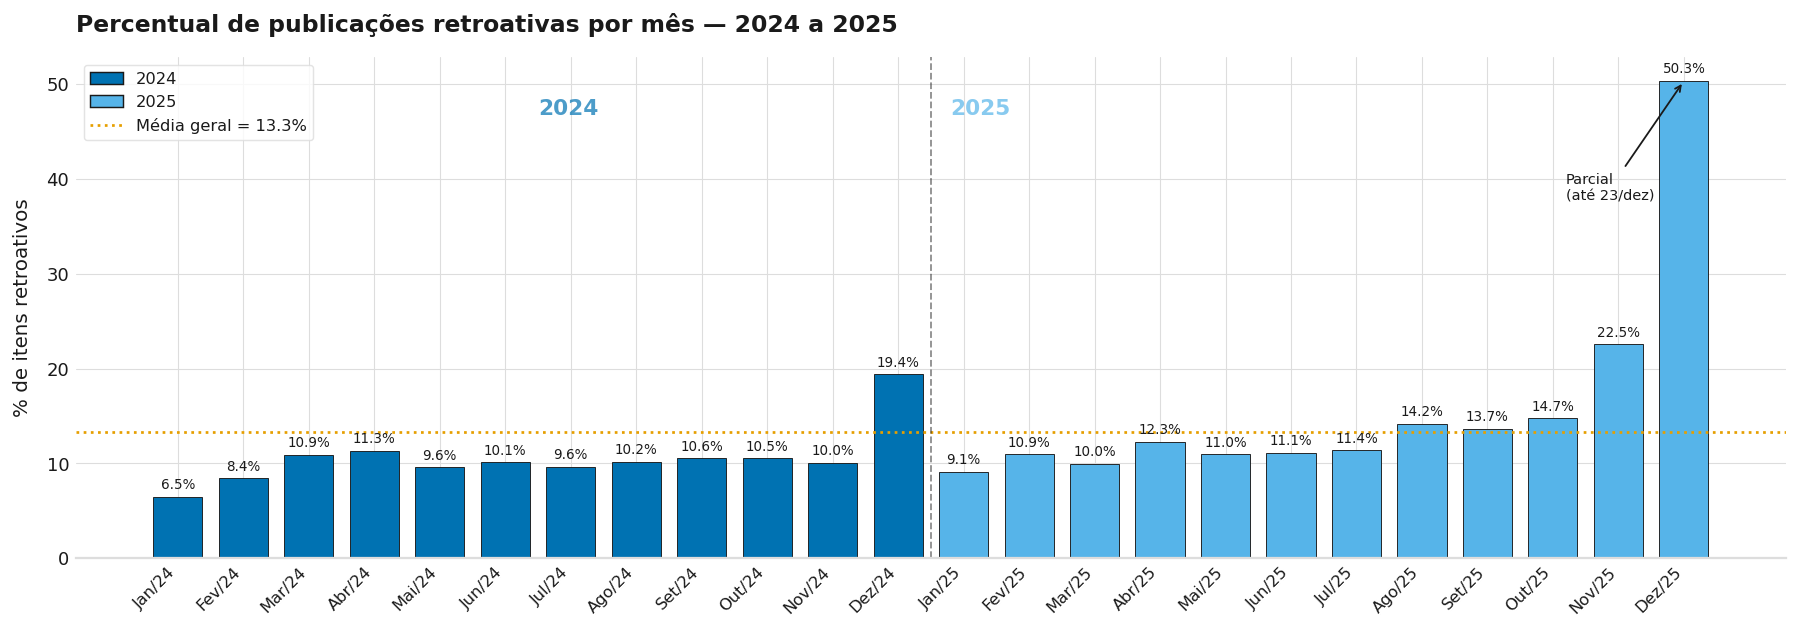

In [23]:
# ── 9.2 Evolução de publicações retroativas por mês — 2024 a 2025 ───────────
#
# A flag é recomputada combinando as duas colunas de data de resultado:
#   - data_resultado_pncp: 100% cobertura em 2025, 13.6% em 2024
#   - data_resultado     : 86.4% cobertura em 2024, ~0% em 2025
# Usa a melhor disponível por item: data_resultado_pncp.fillna(data_resultado)
# Dez/2025 é parcial (até 23/dez) — interpretar com cautela.

MESES_PT = {1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
            7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'}

df_r = df_eda.copy()
df_r['data_pub']      = pd.to_datetime(df_r['data_publicacao_pncp'],  errors='coerce')
df_r['data_res_pncp'] = pd.to_datetime(df_r['data_resultado_pncp'],   errors='coerce')
df_r['data_res']      = pd.to_datetime(df_r['data_resultado'],         errors='coerce')
df_r['data_res_best'] = df_r['data_res_pncp'].fillna(df_r['data_res'])

df_r = df_r[
    df_r['data_pub'].dt.year.isin([2024, 2025]) &
    df_r['data_pub'].notna() &
    df_r['data_res_best'].notna()
].copy()
df_r['retro']   = (df_r['data_res_best'] < df_r['data_pub']).astype(int)
df_r['ano']     = df_r['data_pub'].dt.year
df_r['mes']     = df_r['data_pub'].dt.month
df_r['ano_mes'] = df_r['data_pub'].dt.to_period('M')

mensal_r = (
    df_r.groupby('ano_mes')
    .agg(n_total=('retro','count'), n_retro=('retro','sum'),
         ano=('ano','first'), mes=('mes','first'))
    .reset_index()
)
mensal_r['pct_retro']  = mensal_r['n_retro'] / mensal_r['n_total'] * 100
mensal_r['mes_label']  = [f"{MESES_PT[m]}/{str(a)[2:]}" for m, a in zip(mensal_r['mes'], mensal_r['ano'])]

CORES_ANO = {2024: AZUL_OI, 2025: CIANO_OI}
cores = [CORES_ANO[a] for a in mensal_r['ano']]
media_geral = mensal_r['pct_retro'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(
    range(len(mensal_r)), mensal_r['pct_retro'],
    color=cores, edgecolor=CINZA_TEXT, linewidth=0.5, width=0.75,
)

for bar, val in zip(bars, mensal_r['pct_retro']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + mensal_r['pct_retro'].max() * 0.01,
        f"{val:.1f}%",
        ha='center', va='bottom', fontsize=7.5, color=CINZA_TEXT,
    )

ax.axhline(media_geral, color=LARANJA_OI, linewidth=1.5, linestyle=':',
           label=f'Média geral = {media_geral:.1f}%')

# Anotação dez/2025 parcial
idx_dez25 = mensal_r[(mensal_r['ano'] == 2025) & (mensal_r['mes'] == 12)].index
if len(idx_dez25):
    pos = mensal_r.index.get_loc(idx_dez25[0])
    ax.annotate(
        'Parcial\n(até 23/dez)',
        xy=(pos, mensal_r.loc[idx_dez25[0], 'pct_retro']),
        xytext=(pos - 1.8, mensal_r['pct_retro'].max() * 0.75),
        fontsize=8, color=CINZA_TEXT,
        arrowprops=dict(arrowstyle='->', color=CINZA_TEXT, lw=1.0),
    )

# Divisória de ano
idx_jan25 = mensal_r[(mensal_r['ano'] == 2025) & (mensal_r['mes'] == 1)].index
if len(idx_jan25):
    pos_div = mensal_r.index.get_loc(idx_jan25[0]) - 0.5
    ax.axvline(pos_div, color=CINZA_TEXT, linewidth=1.0, linestyle='--', alpha=0.5)
    ax.text(pos_div - 6.0, mensal_r['pct_retro'].max() * 0.93, '2024',
            fontsize=12, fontweight='bold', color=AZUL_OI, alpha=0.7)
    ax.text(pos_div + 0.3, mensal_r['pct_retro'].max() * 0.93, '2025',
            fontsize=12, fontweight='bold', color=CIANO_OI, alpha=0.7)

ax.set_xticks(range(len(mensal_r)))
ax.set_xticklabels(mensal_r['mes_label'], rotation=45, ha='right', fontsize=9)

from matplotlib.patches import Patch
leg = [
    Patch(facecolor=AZUL_OI,  edgecolor=CINZA_TEXT, label='2024'),
    Patch(facecolor=CIANO_OI, edgecolor=CINZA_TEXT, label='2025'),
] + ax.get_legend_handles_labels()[0]
ax.legend(handles=leg, fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)

_estilizar(
    ax,
    titulo='Percentual de publicações retroativas por mês — 2024 a 2025',
    xlabel='',
    ylabel='% de itens retroativos',
    despine_left=True,
)
salvar_ou_mostrar(fig)

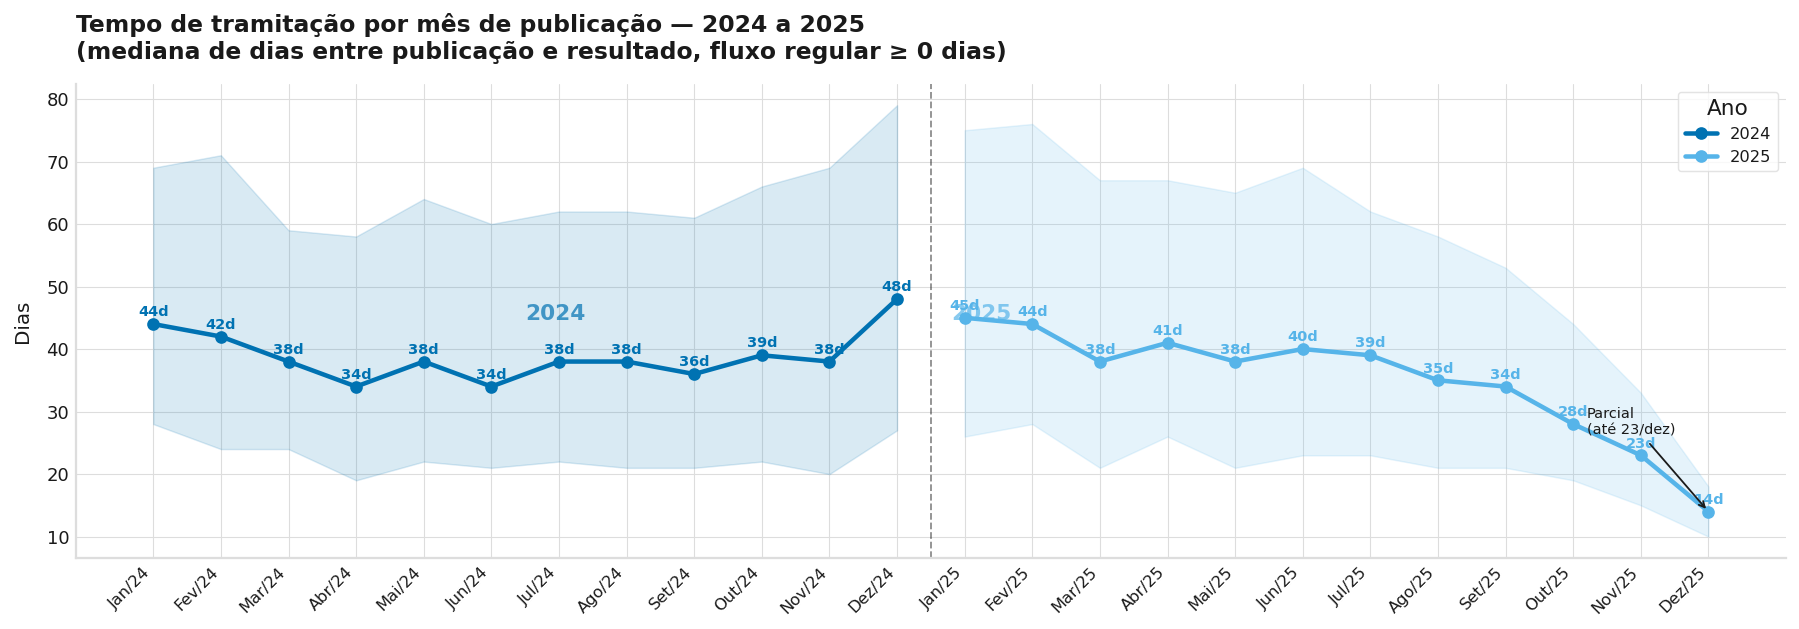

In [22]:
# ── 9.3 Tempo de tramitação (publicação → resultado) por mês — 2024 a 2025 ──
#
# Usa a melhor data de resultado disponível por item:
#   data_resultado_pncp (100% em 2025, 13.6% em 2024) preenchida com
#   data_resultado      (86.4% em 2024, ~0% em 2025).
# Restrito a fluxo regular (dias >= 0). Dez/2025 parcial (até 23/dez).

MESES_PT = {1:'Jan',2:'Fev',3:'Mar',4:'Abr',5:'Mai',6:'Jun',
            7:'Jul',8:'Ago',9:'Set',10:'Out',11:'Nov',12:'Dez'}

df_tr = df_eda.copy()
df_tr['data_pub']      = pd.to_datetime(df_tr['data_publicacao_pncp'], errors='coerce')
df_tr['data_res_pncp'] = pd.to_datetime(df_tr['data_resultado_pncp'],  errors='coerce')
df_tr['data_res']      = pd.to_datetime(df_tr['data_resultado'],        errors='coerce')
df_tr['data_res_best'] = df_tr['data_res_pncp'].fillna(df_tr['data_res'])
df_tr['dias']          = (df_tr['data_res_best'] - df_tr['data_pub']).dt.days

df_tr = df_tr[
    df_tr['data_pub'].dt.year.isin([2024, 2025]) &
    df_tr['data_pub'].notna() &
    (df_tr['dias'] >= 0)
].copy()
df_tr['ano'] = df_tr['data_pub'].dt.year
df_tr['mes'] = df_tr['data_pub'].dt.month
df_tr['ano_mes'] = df_tr['data_pub'].dt.to_period('M')

resumo = (
    df_tr.groupby('ano_mes')['dias']
    .agg(mediana='median',
         p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .reset_index()
)
resumo['ano'] = resumo['ano_mes'].dt.year
resumo['mes'] = resumo['ano_mes'].dt.month
resumo['mes_label'] = [f"{MESES_PT[m]}/{str(a)[2:]}" for m, a in zip(resumo['mes'], resumo['ano'])]

CORES_ANO = {2024: AZUL_OI, 2025: CIANO_OI}

fig, ax = plt.subplots(figsize=(14, 5))

for ano, grupo in resumo.groupby('ano'):
    cor = CORES_ANO[ano]
    ax.fill_between(
        grupo.index, grupo['p25'], grupo['p75'],
        alpha=0.15, color=cor,
    )
    ax.plot(
        grupo.index, grupo['mediana'],
        color=cor, linewidth=2.5, marker='o', markersize=6, label=str(ano),
    )
    for i, row in grupo.iterrows():
        ax.text(i, row['mediana'] + 0.8, f"{row['mediana']:.0f}d",
                ha='center', va='bottom', fontsize=8, color=cor, fontweight='bold')

# Divisória entre anos
idx_jan25 = resumo[(resumo['ano'] == 2025) & (resumo['mes'] == 1)].index
if len(idx_jan25):
    pos_div = idx_jan25[0] - 0.5
    ax.axvline(pos_div, color=CINZA_TEXT, linewidth=1.0, linestyle='--', alpha=0.5)
    ax.text(pos_div - 6.0, resumo['mediana'].max() * 0.93, '2024',
            fontsize=12, fontweight='bold', color=AZUL_OI, alpha=0.7)
    ax.text(pos_div + 0.3, resumo['mediana'].max() * 0.93, '2025',
            fontsize=12, fontweight='bold', color=CIANO_OI, alpha=0.7)

# Anotação dez/2025 parcial
idx_dez25 = resumo[(resumo['ano'] == 2025) & (resumo['mes'] == 12)].index
if len(idx_dez25):
    pos = idx_dez25[0]
    ax.annotate(
        'Parcial\n(até 23/dez)',
        xy=(pos, resumo.loc[pos, 'mediana']),
        xytext=(pos - 1.8, resumo['mediana'].max() * 0.55),
        fontsize=8, color=CINZA_TEXT,
        arrowprops=dict(arrowstyle='->', color=CINZA_TEXT, lw=1.0),
    )

ax.set_xticks(resumo.index)
ax.set_xticklabels(resumo['mes_label'], rotation=45, ha='right', fontsize=9)
ax.legend(title='Ano', fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)

_estilizar(
    ax,
    titulo='Tempo de tramitação por mês de publicação — 2024 a 2025\n'
           '(mediana de dias entre publicação e resultado, fluxo regular ≥ 0 dias)',
    xlabel='',
    ylabel='Dias',
)
salvar_ou_mostrar(fig)

## 10. Análise por Órgão Contratante

In [ ]:
# ── Setup: agregação por órgão ───────────────────────────────────────────────
# Mínimo de 500 itens para garantir representatividade no RE médio.
MIN_ITENS = 500
TOP_N     = 15

def truncar(nome, n=45):
    return nome if len(nome) <= n else nome[:n].rstrip() + '…'

orgao_stats = (
    df_eda[df_eda['orgao_entidade_razao_social'].notna()]
    .groupby('orgao_entidade_razao_social')
    .agg(
        n_itens   = ('id_compra_item',        'count'),
        n_compras = ('id_compra',              'nunique'),
        re_medio  = ('ratio_preco_total_wins', 'mean'),
        valor_mediano = ('valor_total_homologado', 'median'),
    )
    .reset_index()
)
orgao_stats['nome_curto'] = orgao_stats['orgao_entidade_razao_social'].apply(truncar)
orgao_stats_min = orgao_stats[orgao_stats['n_itens'] >= MIN_ITENS].copy()
print(f'Órgãos únicos: {len(orgao_stats):,} | com >= {MIN_ITENS} itens: {len(orgao_stats_min):,}')

In [ ]:
# ── 10.1 Top 15 órgãos por volume de itens homologados ──────────────────────

top_vol = orgao_stats.nlargest(TOP_N, 'n_itens').sort_values('n_itens')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_vol['nome_curto'], top_vol['n_itens'] / 1000,
    color=AZUL_OI, edgecolor=CINZA_TEXT, linewidth=0.6, height=0.65,
)
_hachura_barras(ax)
for bar, val in zip(bars, top_vol['n_itens']):
    ax.text(
        bar.get_width() + top_vol['n_itens'].max() / 1000 * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val/1000:.0f}k', va='center', fontsize=9,
        fontweight='bold', color=CINZA_TEXT,
    )
_estilizar(
    ax,
    titulo=f'Top {TOP_N} órgãos por volume de itens homologados',
    xlabel='Número de itens (milhares)',
    ylabel='',
    despine_left=True,
)
salvar_ou_mostrar(fig)

In [ ]:
# ── 10.2 Índice de economicidade (RE médio) por órgão ───────────────────────
# Restrito a órgãos com >= MIN_ITENS para representatividade.
# RE < 1 indica desconto; RE > 1 indica pagamento acima do estimado.

melhores = orgao_stats_min.nsmallest(TOP_N, 're_medio').sort_values('re_medio', ascending=False)
piores   = orgao_stats_min.nlargest(TOP_N,  're_medio').sort_values('re_medio', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, dados, titulo, cor in [
    (axes[0], melhores, f'Top {TOP_N} — Maior desconto (menor RE)', VERDE_OI),
    (axes[1], piores,   f'Top {TOP_N} — Menor desconto (maior RE)', VERMELHO_OI),
]:
    bars = ax.barh(
        dados['nome_curto'], dados['re_medio'],
        color=cor, edgecolor=CINZA_TEXT, linewidth=0.6, height=0.65,
    )
    _hachura_barras(ax)
    for bar, val in zip(bars, dados['re_medio']):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8,
            fontweight='bold', color=CINZA_TEXT,
        )
    ax.axvline(1.0, color=PRETO_OI, linewidth=1.5, linestyle='--', alpha=0.6,
               label='RE = 1,0')
    ax.legend(fontsize=8, framealpha=0.8)
    _estilizar(ax, titulo=titulo, xlabel='RE médio', ylabel='', despine_left=True, tight=False)

fig.tight_layout()
salvar_ou_mostrar(fig)

In [ ]:
# ── 10.3 Volume de itens × RE médio — órgãos com >= MIN_ITENS itens ─────────
# Mostra se órgãos maiores (mais compras) conseguem melhores preços.

import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    orgao_stats_min['n_itens'] / 1000,
    orgao_stats_min['re_medio'],
    alpha=0.4, s=30, color=AZUL_OI, edgecolors='none',
)

# Destacar os 5 maiores em volume
top5 = orgao_stats_min.nlargest(5, 'n_itens')
ax.scatter(
    top5['n_itens'] / 1000, top5['re_medio'],
    color=VERMELHO_OI, s=80, zorder=5, edgecolors=CINZA_TEXT, linewidths=0.7,
)
for _, row in top5.iterrows():
    ax.annotate(
        row['nome_curto'],
        xy=(row['n_itens'] / 1000, row['re_medio']),
        xytext=(8, 0), textcoords='offset points',
        fontsize=7.5, color=CINZA_TEXT,
        arrowprops=dict(arrowstyle='-', color=CINZA_GRID, lw=0.8),
    )

ax.axhline(1.0, color=PRETO_OI, linewidth=1.5, linestyle='--', alpha=0.5,
           label='RE = 1,0  (sem desconto)')
ax.axhline(orgao_stats_min['re_medio'].mean(), color=LARANJA_OI,
           linewidth=1.2, linestyle=':', label=f"RE médio geral = {orgao_stats_min['re_medio'].mean():.3f}")
ax.legend(fontsize=9, framealpha=0.8, edgecolor=CINZA_GRID)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k'))
_estilizar(
    ax,
    titulo='Volume de itens vs. Índice de Economicidade (RE) por órgão',
    xlabel='Número de itens (milhares)',
    ylabel='RE médio',
)
salvar_ou_mostrar(fig)

In [ ]:
# ── 10.4 Top 15 órgãos por valor total homologado ───────────────────────────

top_valor = (
    df_eda[df_eda['orgao_entidade_razao_social'].notna()]
    .groupby('orgao_entidade_razao_social')
    .agg(valor_total=('valor_total_homologado', 'sum'))
    .reset_index()
)
top_valor['nome_curto'] = top_valor['orgao_entidade_razao_social'].apply(truncar)
top_valor = top_valor.nlargest(TOP_N, 'valor_total').sort_values('valor_total')

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(
    top_valor['nome_curto'], top_valor['valor_total'] / 1e9,
    color=LARANJA_OI, edgecolor=CINZA_TEXT, linewidth=0.6, height=0.65,
)
_hachura_barras(ax)
for bar, val in zip(bars, top_valor['valor_total']):
    ax.text(
        bar.get_width() + top_valor['valor_total'].max() / 1e9 * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e9:.1f} bi', va='center', fontsize=9,
        fontweight='bold', color=CINZA_TEXT,
    )
_estilizar(
    ax,
    titulo=f'Top {TOP_N} órgãos por valor total homologado',
    xlabel='Valor total homologado (R$ bilhões)',
    ylabel='',
    despine_left=True,
)
salvar_ou_mostrar(fig)